# Analisis Klasterisasi Kerentanan Bencana Kecamatan di Provinsi Aceh
# Berdasarkan Data Potensi Desa 2024 Menggunakan Metode SKATER

---

**Metode:** SKATER (*Spatial 'K'luster Analysis by Tree Edge Removal*)  
**Data:** Data Potensi Desa (PODES) 2024 – Provinsi Aceh  
**Unit Analisis:** 290 Kecamatan di Provinsi Aceh  

---

## Referensi Metodologi

1. Assunção, R. M., Neves, M. C., Câmara, G., & da Costa Freitas, C. (2006). Efficient regionalization techniques for socio‐economic geographical units using minimum spanning trees. *International Journal of Geographical Information Science*, 20(7), 797–811. https://doi.org/10.1080/13658810600665111

2. Duque, J. C., Ramos, R., & Suriñach, J. (2007). Supervised regionalization methods: A survey. *International Regional Science Review*, 30(3), 195–220. https://doi.org/10.1177/0160017607301605

3. Anselin, L. (1995). Local indicators of spatial association—LISA. *Geographical Analysis*, 27(2), 93–115. https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

4. Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

5. Davies, D. L., & Bouldin, D. W. (1979). A cluster separation measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224–227. https://doi.org/10.1109/TPAMI.1979.4766909

6. Caliński, T., & Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics-Theory and Methods*, 3(1), 1–27. https://doi.org/10.1080/03610927408827101

---

## Tahap 1: Import Library dan Konfigurasi Lingkungan

Library yang digunakan meliputi:
- **geopandas & libpysal**: Pemrosesan data spasial dan pembobotan spasial
- **spopt**: Implementasi algoritma SKATER untuk regionalisasi spasial
- **sklearn**: Metrik evaluasi klaster (Silhouette, Davies-Bouldin, Calinski-Harabasz)
- **networkx**: Analisis graf dan pohon merentang minimum (MST)
- **matplotlib & seaborn**: Visualisasi

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import os
import warnings
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from libpysal.weights import Queen, KNN, W
from spopt.region import Skater
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)
# Uji Autokorelasi Spasial (Moran's I)
from esda.moran import Moran
# Uji Statistik Pasca-Klasterisasi
from scipy.stats import kruskal
import scikit_posthocs as sp
# Konfigurasi plot
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_style('whitegrid')
# Direktori output
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Konstanta
ATTRS = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
K_RANGE = [2, 3, 4]
FLOOR_SIZE = 10  # Batas minimum jumlah anggota per klaster (floor constraint)
PREMIUM_COLORS = ['#1565C0', '#E53935', '#2E7D32', '#F57F17', '#6A1B9A']
print("Library berhasil dimuat.")
print(f"Output grafik disimpan ke: {os.path.abspath(OUTPUT_DIR)}")


Library berhasil dimuat.
Output grafik disimpan ke: /run/media/andrian-fajar-fahmi/UBUNTU_BOOT/ProjectIndividuDatMin/output


## Tahap 2: Pemuatan dan Eksplorasi Data

Data yang digunakan terdiri dari:
1. **Data atribut** (preprocessed): 290 kecamatan × 10 variabel kerentanan bencana (sudah distandardisasi)
2. **Data spasial** (shapefile): Poligon batas kecamatan Provinsi Aceh

### Variabel Penelitian (X1–X10)

| Komponen | Kode | Nama Variabel |
|:---------|:----:|:--------------|
| **Keterpaparan Bencana** | X1 | Proporsi desa terdampak bencana alam |
| | X2 | Proporsi desa dengan permukiman di bantaran sungai |
| **Kerentanan Lingkungan & Sosial** | X3 | Proporsi desa mengalami KLB/wabah penyakit |
| | X4 | Proporsi desa dengan pencemaran lingkungan |
| | X5 | Proporsi desa dengan permukiman kumuh |
| **Kapasitas Mitigasi & Respons** | X6 | Proporsi desa dengan upaya mitigasi bencana |
| | X7 | Proporsi desa dengan tenaga kesehatan |
| | X8 | Proporsi desa dengan fasilitas kesehatan |
| **Faktor Geografis Inheren** | X9 | Proporsi desa bertopografi berlereng/bergunung |
| | X10 | Proporsi desa berlokasi di pesisir/dekat laut |

In [2]:
# ============================================================
# PEMUATAN DATA
# ============================================================

# Muat data atribut (preprocessed/standardized)
df = pd.read_excel('Data_Datmin_Preprocessed (1).xlsx')

# Muat data spasial
gdf_raw = gpd.read_file('Peta_Aceh_Update.shp')

print(f"Dimensi data atribut : {df.shape[0]} kecamatan × {df.shape[1]} kolom")
print(f"Dimensi data spasial : {gdf_raw.shape[0]} fitur geometri")
print(f"\nKolom data atribut: {df.columns.tolist()}")
print(f"Kolom data spasial: {gdf_raw.columns.tolist()}")

Dimensi data atribut : 290 kecamatan × 13 kolom
Dimensi data spasial : 358 fitur geometri

Kolom data atribut: ['Kabupaten', 'Kecamatan', 'Jumlah Desa', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
Kolom data spasial: ['geometry']


In [3]:
# ============================================================
# EKSPLORASI DATA ATRIBUT
# ============================================================

print("Statistik Deskriptif Data (Standardized):")
print("=" * 80)
display(df[ATTRS].describe().round(4))

Statistik Deskriptif Data (Standardized):


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
count,290.0000,290.0000,290.0000,290.0000,290.0000,290.0000,290.0000,290.0000,290.0000,290.0000
mean,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0017,1.0017,1.0017,1.0017,1.0017,1.0017,1.0017,1.0017,1.0017,1.0017
min,-1.0281,-0.5448,-0.3201,-0.5197,-0.2200,-0.3440,-4.2795,-1.1157,-0.7493,-0.6012
25%,-0.8610,-0.5448,-0.3201,-0.5197,-0.2200,-0.3440,-0.3379,-0.5590,-0.7493,-0.6012
50%,-0.2865,-0.5448,-0.3201,-0.5197,-0.2200,-0.3440,0.2269,-0.2428,-0.4896,-0.6012
75%,0.5711,0.1936,-0.3201,0.0307,-0.2200,-0.2730,0.7282,0.2003,0.4243,0.3185
max,2.6043,6.1009,7.7974,3.9058,6.9897,4.2865,1.0271,6.1221,2.1355,3.3842


In [4]:
# ============================================================
# RINGKASAN DATA PER KABUPATEN/KOTA
# ============================================================

kab_summary = df.groupby('Kabupaten').agg(
    Jumlah_Kecamatan=('Kecamatan', 'count'),
    Total_Desa=('Jumlah Desa', 'sum')
).reset_index()

print(f"\nJumlah Kabupaten/Kota: {kab_summary.shape[0]}")
print(f"Total Kecamatan      : {kab_summary['Jumlah_Kecamatan'].sum()}")
print(f"Total Desa           : {int(kab_summary['Total_Desa'].sum())}")
display(kab_summary.sort_values('Jumlah_Kecamatan', ascending=False).head(10))


Jumlah Kabupaten/Kota: 23
Total Kecamatan      : 290
Total Desa           : 6515


,Kabupaten,Jumlah_Kecamatan,Total_Desa
10,Aceh Utara,27,852
9,Aceh Timur,24,514
2,Aceh Besar,23,603
20,Pidie,23,731
4,Aceh Selatan,18,260
12,Bireuen,17,609
8,Aceh Tenggara,16,385
7,Aceh Tengah,14,295
0,Aceh Barat,12,321
6,Aceh Tamiang,12,216


In [5]:
# ============================================================
# CEK KELENGKAPAN DATA (MISSING VALUES)
# ============================================================

missing = df[ATTRS].isnull().sum()
print("Missing values per variabel:")
print(missing.to_string())
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\n✓ Tidak ada missing values. Data siap digunakan.")

Missing values per variabel:
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0

Total missing values: 0

✓ Tidak ada missing values. Data siap digunakan.


## Tahap 3: Penggabungan Data Spasial dan Atribut & Penanganan Multi-Geometri

Shapefile kecamatan Provinsi Aceh (`Peta_Aceh_Update.shp`) memuat **358 fitur geometri poligon**. Hal ini terjadi karena wilayah kepulauan (seperti gugusan Pulo Aceh), enklave, dan pecahan multipart terpisah menjadi poligon tersendiri (*singlepart*), sementara data tabular PODES 2024 mencakup **290 kecamatan administratif definitif**.

Sebanyak 68 geometri tambahan (indeks 290–357) merepresentasikan **13,18% dari total luas daratan Aceh** dan semuanya berbatasan langsung (*touching*) atau berdekatan dengan 290 kecamatan utama. Jika 68 geometri ini diabaikan atau hanya dijadikan latar belakang pasif, peta klaster akan memiliki area kosong/putih (*holes*).

Oleh karena itu, dilakukan **Spatial Boundary Union**:
1. Setiap poligon pecahan dari 68 geometri tersebut dipetakan ke kecamatan induknya di antara 290 kecamatan yang berbatasan langsung (berdasarkan panjang batas bersama maksimum atau jarak terdekat).
2. Geometri pecahan digabungkan secara spasial (`unary_union`) ke poligon kecamatan induknya.
3. Hasilnya adalah **290 kecamatan dengan geometri wilayah yang 100% utuh dan kontinu**, yang kemudian digabungkan secara presisi dengan data atribut kerentanan bencana.


In [6]:
# ============================================================
# PENGGABUNGAN DATA SPASIAL DAN ATRIBUT & RESOLUSI GEOMETRI UTUH
# ============================================================
from shapely.ops import unary_union

# Pisahkan 290 unit kecamatan utama dan 68 geometri pecahan/pulau
gdf_base = gdf_raw.iloc[:290].copy().reset_index(drop=True)
gdf_extra = gdf_raw.iloc[290:].copy()

# Petakan setiap poligon pecahan ke kecamatan induk yang berbatasan langsung
geom_mapping = {}
for idx, row in gdf_extra.iterrows():
    touching_lengths = {}
    for i_base, row_base in gdf_base.iterrows():
        if row.geometry.touches(row_base.geometry):
            touching_lengths[i_base] = row.geometry.intersection(row_base.geometry).length
        elif row.geometry.intersects(row_base.geometry):
            touching_lengths[i_base] = row.geometry.intersection(row_base.geometry).area
            
    if touching_lengths:
        best_match = max(touching_lengths, key=touching_lengths.get)
    else:
        # Jika pulau di perairan lepas, tautkan ke kecamatan terdekat
        dists = gdf_base.distance(row.geometry)
        best_match = dists.idxmin()
    geom_mapping[idx] = best_match

# Satukan geometri pecahan ke kecamatan induknya (Spatial Union)
complete_geoms = gdf_base.geometry.copy()
for idx_extra, idx_base in geom_mapping.items():
    complete_geoms.loc[idx_base] = unary_union([complete_geoms.loc[idx_base], gdf_extra.loc[idx_extra].geometry])

# Buat GeoDataFrame lengkap dengan 290 kecamatan
gdf = gdf_base.copy()
gdf.geometry = complete_geoms

# Gabungkan data atribut kerentanan bencana (PODES 2024)
for col in df.columns:
    gdf[col] = df[col].values

# Perbarui centroid untuk representasi titik spasial
gdf['centroid_x'] = gdf.geometry.centroid.x
gdf['centroid_y'] = gdf.geometry.centroid.y

print(f"GeoDataFrame: {gdf.shape[0]} kecamatan × {gdf.shape[1]} kolom")
print(f"✓ 68 geometri pulau/pecahan (13.18% luas wilayah) berhasil disatukan ke 290 kecamatan induk.")
print(f"✓ Cakupan spasial wilayah Aceh: 100% utuh tanpa wilayah bolong/kosong (Luas area: {gdf.geometry.union_all().area:.4f}).")
print("\nSampel data (5 baris pertama):")
display(gdf[['Kabupaten', 'Kecamatan', 'Jumlah Desa'] + ATTRS[:5]].head())


GeoDataFrame: 290 kecamatan × 16 kolom
✓ 68 geometri pulau/pecahan (13.18% luas wilayah) berhasil disatukan ke 290 kecamatan induk.
✓ Cakupan spasial wilayah Aceh: 100% utuh tanpa wilayah bolong/kosong (Luas area: 4.6299).

Sampel data (5 baris pertama):


,Kabupaten,Kecamatan,Jumlah Desa,X1,X2,X3,X4,X5
0,Simeulue,Teupah Selatan,19,-1.028108,-0.544814,-0.320116,-0.519740,-0.219988
1,Simeulue,Simeulue Timur,17,0.894911,-0.544814,0.157387,-0.519740,-0.219988
2,Simeulue,Teupah Barat,18,-0.019117,-0.544814,-0.320116,-0.519740,-0.219988
3,Simeulue,Teupah Tengah,12,1.393471,-0.544814,0.356346,0.030695,-0.219988
4,Simeulue,Simeulue Tengah,16,0.561053,-0.544814,-0.320116,-0.519740,-0.219988


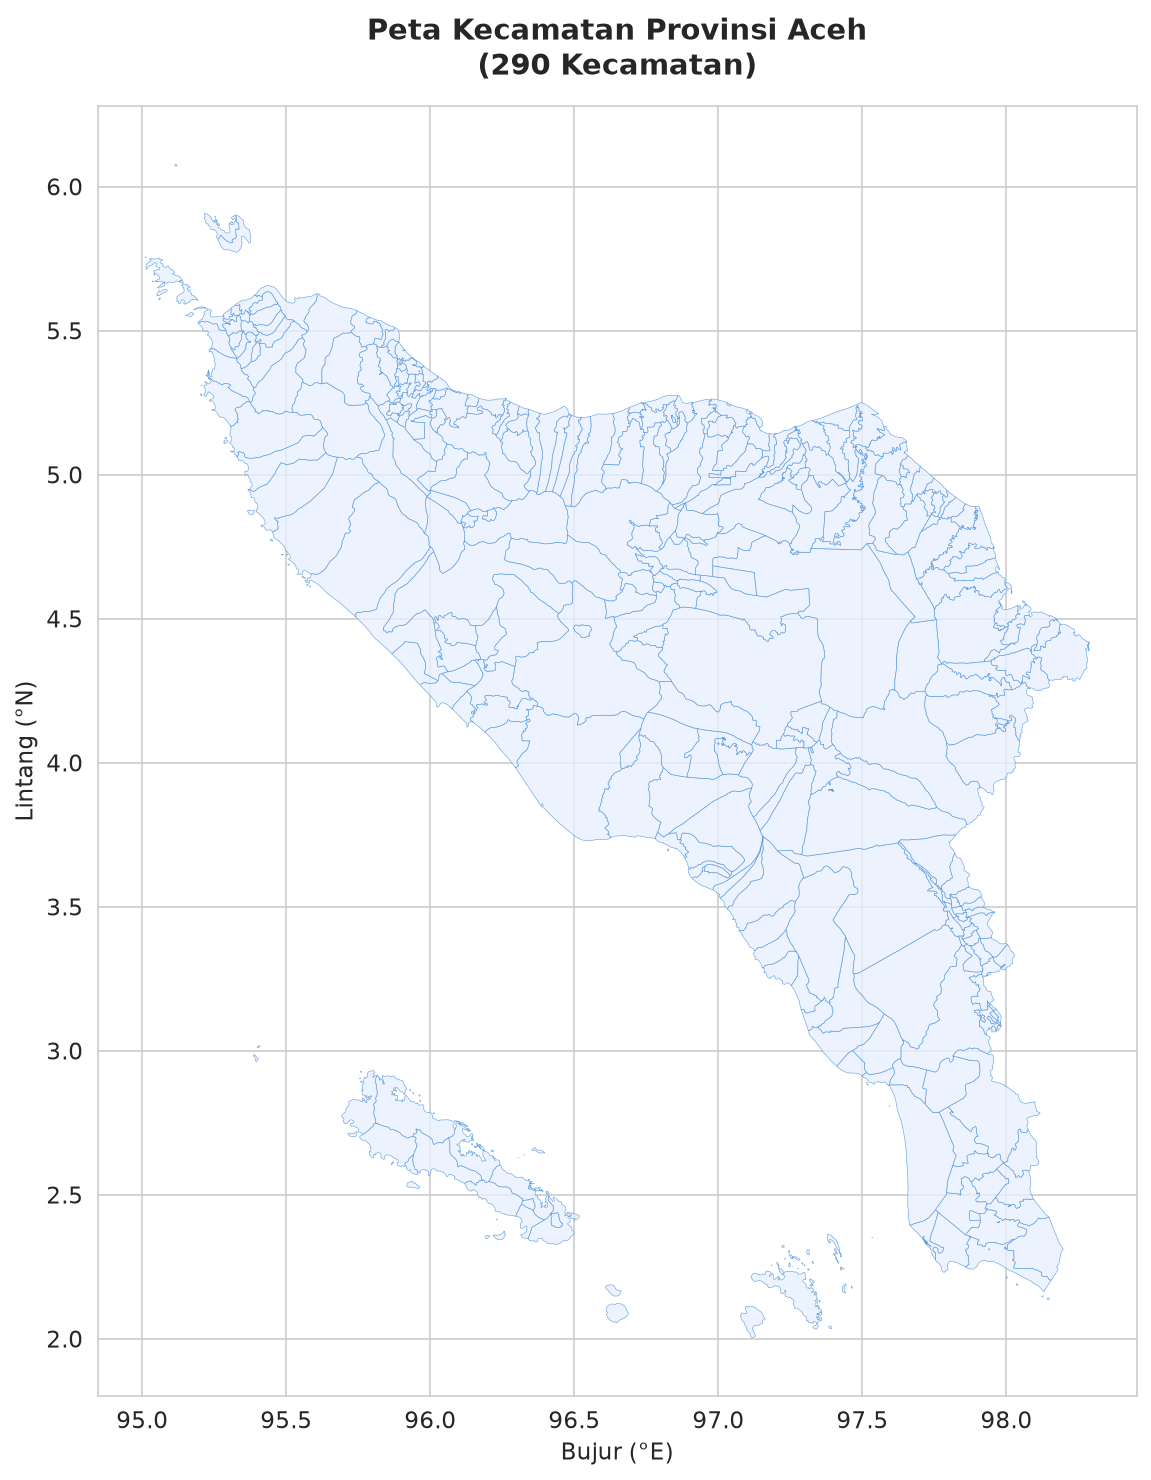

Gambar disimpan: 01_peta_dasar_kecamatan_aceh.png


In [7]:
# ============================================================
# VISUALISASI: Peta Dasar Kecamatan Provinsi Aceh
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf.plot(
    ax=ax,
    color='#E8F0FE',
    edgecolor='#4A90D9',
    linewidth=0.3,
    alpha=0.8
)
ax.set_title('Peta Kecamatan Provinsi Aceh\n(290 Kecamatan)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bujur (°E)', fontsize=11)
ax.set_ylabel('Lintang (°N)', fontsize=11)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_peta_dasar_kecamatan_aceh.png')
plt.show()
print("Gambar disimpan: 01_peta_dasar_kecamatan_aceh.png")

## Tahap 4: Konstruksi Matriks Pembobotan Spasial (*Spatial Weights Matrix*)

### Landasan Teori

Matriks pembobotan spasial (**W**) merupakan komponen fundamental dalam metode SKATER yang mendefinisikan relasi ketetanggaan antar unit spasial (Assunção et al., 2006). Matriks ini merepresentasikan **constraint** spasial yang memastikan bahwa klaster yang dihasilkan terdiri dari unit-unit yang bersebelahan secara geografis (*spatially contiguous*).

### Metode Konstruksi: Queen Contiguity

Pendekatan **Queen contiguity** digunakan, di mana dua kecamatan dianggap bertetangga jika berbagi titik sudut (*vertex*) atau sisi (*edge*) batas wilayah (Anselin, 1995). Metode ini lebih inklusif dibandingkan Rook contiguity karena juga memperhitungkan ketetanggaan diagonal.

### Penanganan Wilayah Terisolasi (*Islands*)

Beberapa kecamatan (terutama di kepulauan) tidak memiliki tetangga langsung berdasarkan Queen contiguity. Untuk memenuhi **syarat konektivitas penuh** yang diperlukan SKATER (graf harus *fully connected*), wilayah terisolasi dihubungkan ke komponen terdekat menggunakan **jarak Euclidean** antar centroid (Duque et al., 2007).

### Syarat dan Asumsi

1. **Konektivitas penuh (*Full connectivity*):** Semua unit harus terhubung dalam satu komponen graf tunggal agar pohon merentang minimum (MST) dapat dibangun.
2. **Simetri:** Jika kecamatan A bertetangga dengan B, maka B juga bertetangga dengan A ($w_{ij} = w_{ji}$).
3. **Non-reflexive:** Unit tidak bertetangga dengan dirinya sendiri ($w_{ii} = 0$).

In [8]:
# ============================================================
# KONSTRUKSI MATRIKS PEMBOBOTAN SPASIAL
# ============================================================

# Langkah 1: Bangun Queen Contiguity
w_queen = Queen.from_dataframe(gdf, use_index=True)

print("=" * 60)
print("QUEEN CONTIGUITY (Sebelum Koreksi Konektivitas)")
print("=" * 60)
print(f"Jumlah unit        : {w_queen.n}")
print(f"Rata-rata tetangga : {w_queen.mean_neighbors:.2f}")
print(f"Min tetangga       : {w_queen.min_neighbors}")
print(f"Max tetangga       : {w_queen.max_neighbors}")
print(f"Jumlah isolat      : {len(w_queen.islands)}")

if w_queen.islands:
    print(f"\nKecamatan isolat:")
    for idx in w_queen.islands:
        print(f"  - [{idx}] {gdf.loc[idx, 'Kecamatan']} ({gdf.loc[idx, 'Kabupaten']})")

QUEEN CONTIGUITY (Sebelum Koreksi Konektivitas)
Jumlah unit        : 290
Rata-rata tetangga : 4.93
Min tetangga       : 0
Max tetangga       : 12
Jumlah isolat      : 8

Kecamatan isolat:
  - [3] Teupah Tengah (Simeulue)
  - [5] Teluk Dalam (Simeulue)
  - [6] Simeulue Cut (Simeulue)
  - [99] Woyla Timur (Aceh Barat)
  - [151] Samalanga (Bireuen)
  - [156] Peudada (Bireuen)
  - [158] Jeumpa (Bireuen)
  - [249] Bukit (Bener Meriah)


In [9]:
# ============================================================
# KOREKSI KONEKTIVITAS: Menghubungkan Komponen Terputus
# ============================================================

def build_connected_weights(gdf, w_queen):
    """
    Membangun matriks pembobotan spasial yang fully connected
    dengan menghubungkan komponen terputus berdasarkan jarak
    centroid terdekat.
    
    Parameters
    ----------
    gdf : GeoDataFrame
        Data spasial kecamatan
    w_queen : libpysal.weights.W
        Matriks Queen contiguity awal
        
    Returns
    -------
    W : libpysal.weights.W
        Matriks pembobotan yang fully connected
    """
    n = len(gdf)
    new_neighbors = {k: list(v) for k, v in w_queen.neighbors.items()}
    new_weights = {k: list(v) for k, v in w_queen.weights.items()}
    
    # Hitung koordinat centroid
    centroids = gdf.geometry.centroid
    coords = np.array([(c.x, c.y) for c in centroids])
    
    def get_components():
        G = nx.Graph()
        G.add_nodes_from(range(n))
        for node, neighs in new_neighbors.items():
            for ne in neighs:
                G.add_edge(node, ne)
        return list(nx.connected_components(G))
    
    # Iteratif menghubungkan komponen
    max_iter = 50
    for iteration in range(max_iter):
        components = get_components()
        if len(components) == 1:
            break
        
        largest_comp = max(components, key=len)
        largest_nodes = np.array(list(largest_comp))
        
        for comp in components:
            if comp == largest_comp:
                continue
            comp_nodes = list(comp)
            
            # Cari pasangan terdekat
            best_dist = float('inf')
            best_pair = None
            for cn in comp_nodes:
                dists = np.sqrt(np.sum((coords[largest_nodes] - coords[cn])**2, axis=1))
                min_idx = np.argmin(dists)
                if dists[min_idx] < best_dist:
                    best_dist = dists[min_idx]
                    best_pair = (cn, largest_nodes[min_idx])
            
            # Tambahkan koneksi dua arah
            a, b = best_pair
            if b not in new_neighbors[a]:
                new_neighbors[a].append(b)
                new_weights[a].append(1.0)
            if a not in new_neighbors[b]:
                new_neighbors[b].append(a)
                new_weights[b].append(1.0)
    
    return W(new_neighbors, new_weights)

# Bangun matriks yang fully connected
w = build_connected_weights(gdf, w_queen)

print("=" * 60)
print("MATRIKS PEMBOBOTAN SPASIAL (Setelah Koreksi Konektivitas)")
print("=" * 60)
print(f"Jumlah unit        : {w.n}")
print(f"Rata-rata tetangga : {w.mean_neighbors:.2f}")
print(f"Min tetangga       : {w.min_neighbors}")
print(f"Max tetangga       : {w.max_neighbors}")
print(f"Jumlah isolat      : {len(w.islands)}")
print(f"\n✓ Graf fully connected: {len(w.islands) == 0}")

MATRIKS PEMBOBOTAN SPASIAL (Setelah Koreksi Konektivitas)
Jumlah unit        : 290
Rata-rata tetangga : 5.00
Min tetangga       : 1
Max tetangga       : 12
Jumlah isolat      : 0

✓ Graf fully connected: True


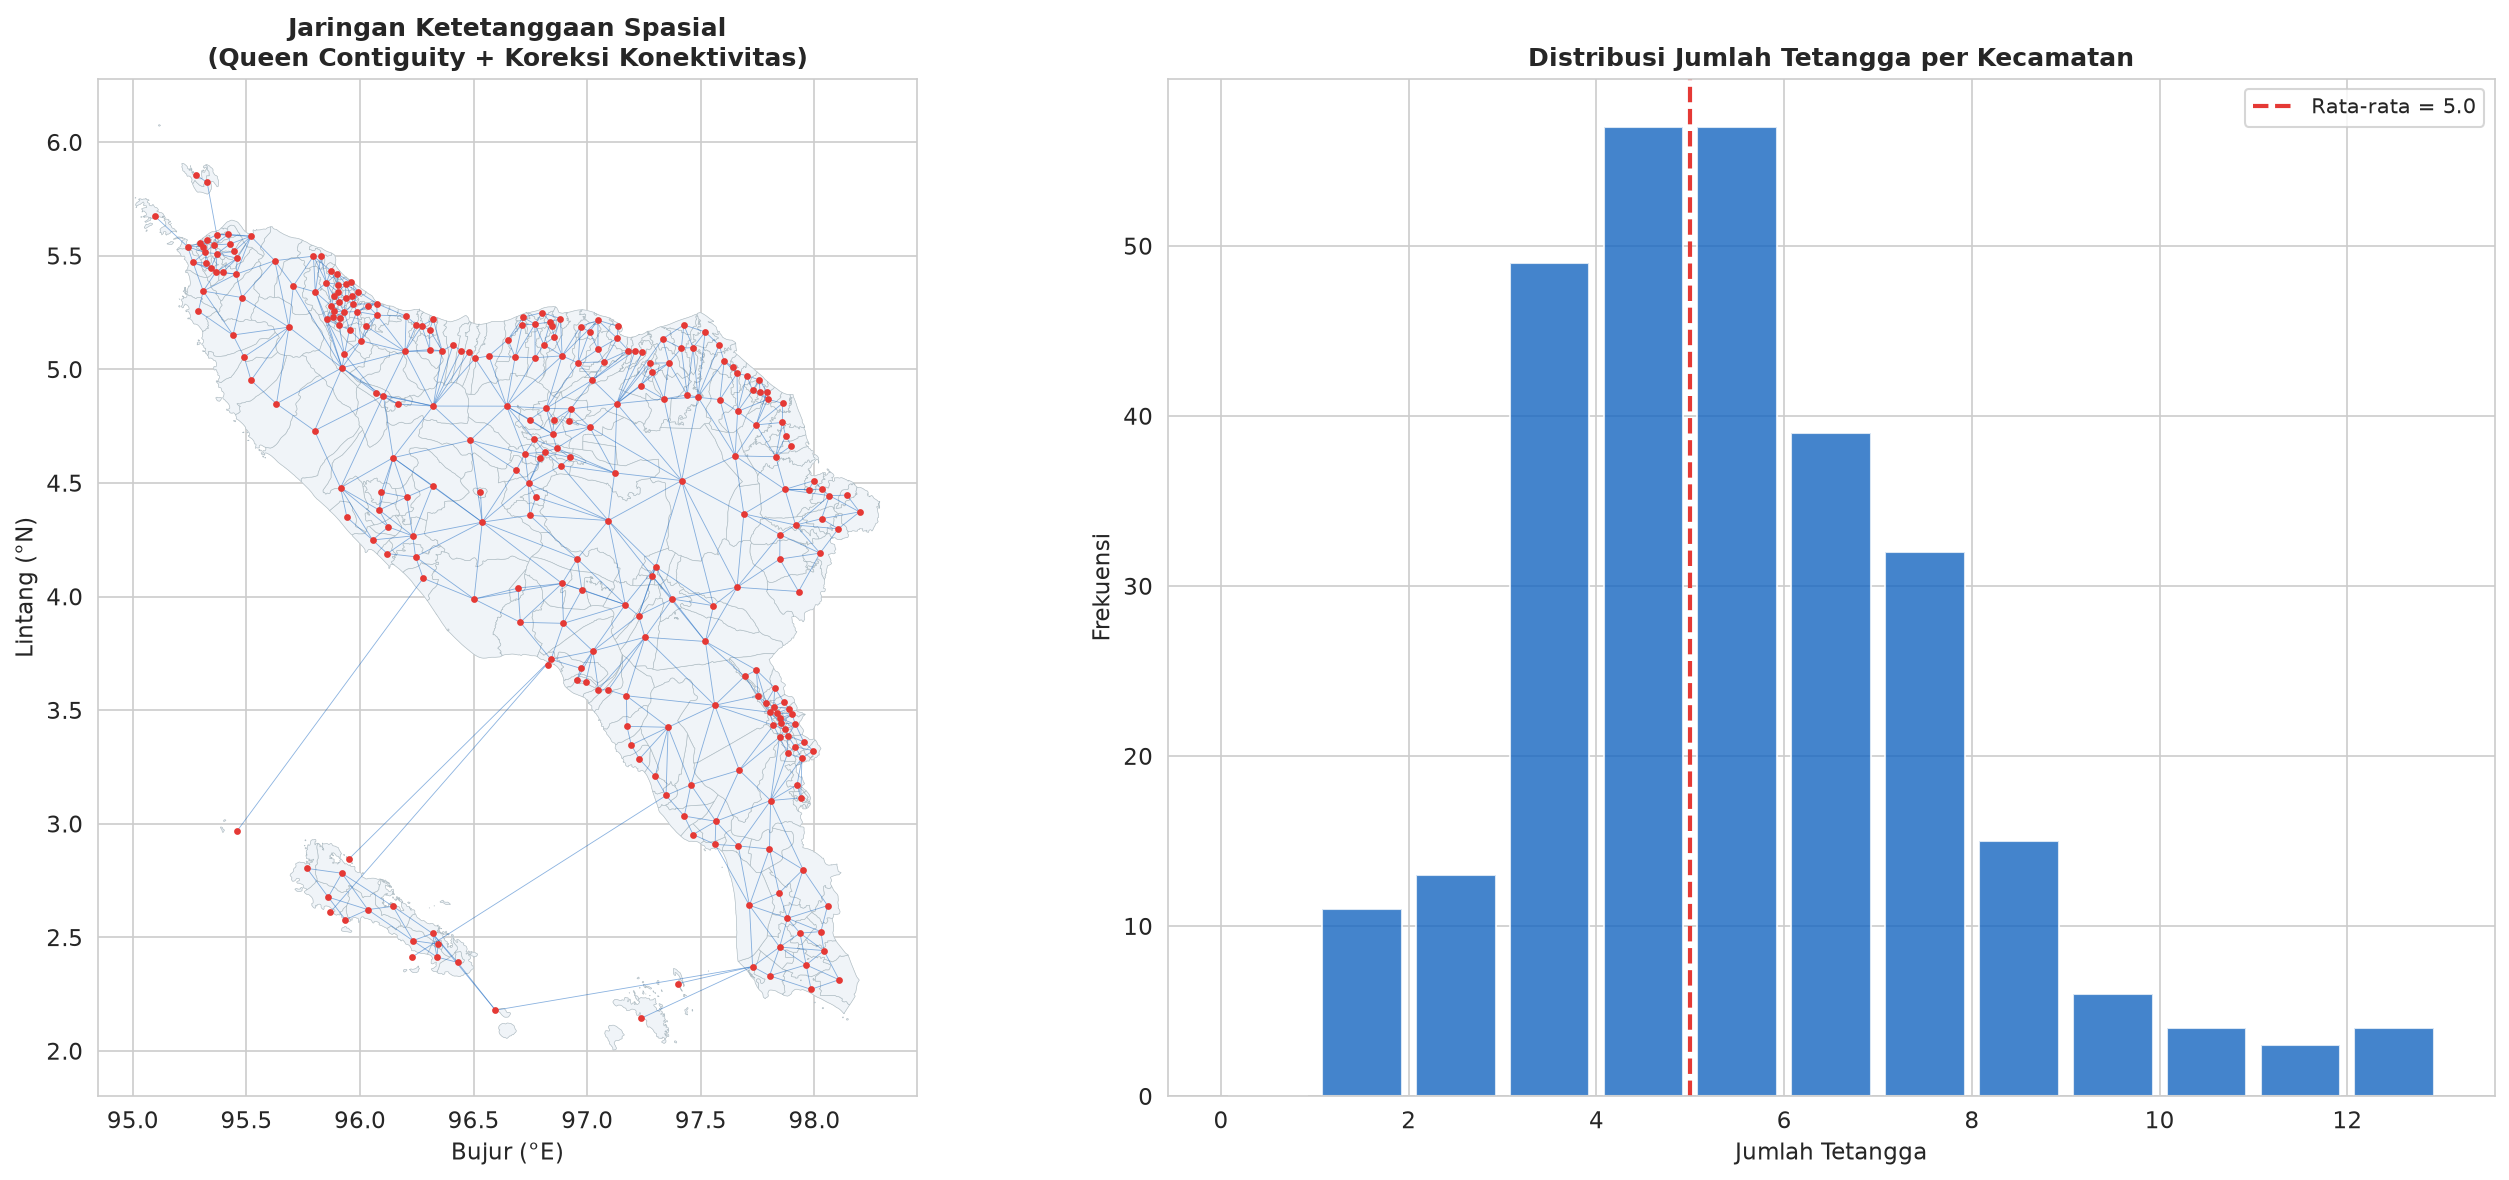

Gambar disimpan: 02_jaringan_ketetanggaan_spasial.png


In [10]:
# ============================================================
# VISUALISASI: Jaringan Ketetanggaan Spasial
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

coords = np.array([(c.x, c.y) for c in gdf.geometry.centroid])

# --- Panel kiri: Peta ketetanggaan ---
ax1 = axes[0]
gdf_raw.plot(ax=ax1, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background: semua 358 geometri
gdf.plot(ax=ax1, color='#F0F4F8', edgecolor='#B0BEC5', linewidth=0.3)
for i in range(len(gdf)):
    for j in w.neighbors[i]:
        if j > i:
            ax1.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                     color='#1565C0', linewidth=0.4, alpha=0.5)
ax1.scatter(coords[:, 0], coords[:, 1], c='#E53935', s=5, zorder=5)
ax1.set_title('Jaringan Ketetanggaan Spasial\n(Queen Contiguity + Koreksi Konektivitas)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Bujur (°E)')
ax1.set_ylabel('Lintang (°N)')
ax1.set_aspect('equal')

# --- Panel kanan: Distribusi jumlah tetangga ---
ax2 = axes[1]
n_neighbors = [len(w.neighbors[i]) for i in range(len(gdf))]
ax2.hist(n_neighbors, bins=range(0, max(n_neighbors)+2), 
         color='#1565C0', edgecolor='white', alpha=0.8, rwidth=0.85)
ax2.axvline(np.mean(n_neighbors), color='#E53935', linestyle='--', linewidth=2,
            label=f'Rata-rata = {np.mean(n_neighbors):.1f}')
ax2.set_title('Distribusi Jumlah Tetangga per Kecamatan', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Jumlah Tetangga')
ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_jaringan_ketetanggaan_spasial.png')
plt.show()
print("Gambar disimpan: 02_jaringan_ketetanggaan_spasial.png")

## Tahap 4b: Uji Autokorelasi Spasial (Global Moran's I)

### Justifikasi Penggunaan Metode SKATER

Sebelum menerapkan SKATER sebagai metode *spatially constrained clustering*, perlu dibuktikan terlebih dahulu bahwa variabel-variabel kerentanan bencana memiliki **autokorelasi spasial** — yaitu kecamatan yang berdekatan secara geografis cenderung memiliki nilai variabel yang serupa.

**Global Moran's I** (Anselin, 1995) digunakan untuk menguji hipotesis ini:
- **H₀:** Tidak ada autokorelasi spasial (distribusi acak)
- **H₁:** Ada autokorelasi spasial positif
- **Keputusan:** Tolak H₀ jika *p-value* < 0,05

Jika Moran's I signifikan positif, maka penggunaan SKATER (yang mempertahankan kontiguitas spasial) **terjustifikasi secara statistik** dibandingkan metode aspatial seperti K-Means.

### Referensi
- Anselin, L. (1995). Local indicators of spatial association—LISA. *Geographical Analysis*, 27(2), 93–115.
- Yamada, H. (2024). Moran's I for multivariate spatial data. *Mathematics*, 12(17), 2746.

In [11]:
# ============================================================
# UJI AUTOKORELASI SPASIAL: GLOBAL MORAN'S I
# ============================================================

print("=" * 70)
print("UJI AUTOKORELASI SPASIAL (GLOBAL MORAN'S I)")
print("Justifikasi penggunaan metode spatially constrained (SKATER)")
print("=" * 70)
print(f"\nMatriks pembobotan: Queen Contiguity (n = {w.n})")
print(f"Taraf signifikansi: α = 0,05")
print(f"Permutasi         : 999\n")

var_labels = {
    'X1': 'Bencana Alam', 'X2': 'Bantaran Sungai', 'X3': 'KLB/Wabah',
    'X4': 'Pencemaran Lingk.', 'X5': 'Permukiman Kumuh',
    'X6': 'Mitigasi Bencana', 'X7': 'Tenaga Kesehatan',
    'X8': 'Fasilitas Kes.', 'X9': 'Berlereng/Gunung', 'X10': 'Pesisir/Laut'
}

moran_results = []
for var in ATTRS:
    mi = Moran(gdf[var].values, w, permutations=999)
    sig = 'Signifikan' if mi.p_sim < 0.05 else 'Tidak Signifikan'
    moran_results.append({
        'Variabel': var,
        'Deskripsi': var_labels[var],
        "Moran's I": round(mi.I, 4),
        'E[I]': round(mi.EI, 4),
        'z-score': round(mi.z_sim, 4),
        'p-value': round(mi.p_sim, 4),
        'Keputusan': sig
    })

moran_df = pd.DataFrame(moran_results)

print("HASIL UJI GLOBAL MORAN'S I PER VARIABEL")
print("-" * 70)
display(moran_df)

# Ringkasan
n_sig = sum(1 for r in moran_results if r['Keputusan'] == 'Signifikan')
print(f"\n{'=' * 70}")
print(f"RINGKASAN:")
print(f"  - Variabel dengan autokorelasi spasial signifikan: {n_sig}/{len(ATTRS)}")
print(f"  - Variabel tanpa autokorelasi spasial signifikan : {len(ATTRS) - n_sig}/{len(ATTRS)}")
if n_sig > len(ATTRS) // 2:
    print(f"\n  → Mayoritas variabel menunjukkan autokorelasi spasial signifikan.")
    print(f"  → Penggunaan metode spatially constrained (SKATER) TERJUSTIFIKASI.")
else:
    print(f"\n  → Autokorelasi spasial tidak dominan pada variabel kerentanan.")

# Simpan tabel
moran_df.to_excel(f'{OUTPUT_DIR}/uji_morans_i.xlsx', index=False)
print(f"\nTabel disimpan: uji_morans_i.xlsx")

UJI AUTOKORELASI SPASIAL (GLOBAL MORAN'S I)
Justifikasi penggunaan metode spatially constrained (SKATER)

Matriks pembobotan: Queen Contiguity (n = 290)
Taraf signifikansi: α = 0,05
Permutasi         : 999

HASIL UJI GLOBAL MORAN'S I PER VARIABEL
----------------------------------------------------------------------


,Variabel,Deskripsi,Moran's I,E[I],z-score,p-value,Keputusan
0,X1,Bencana Alam,0.1272,-0.0035,3.2459,0.001,Signifikan
1,X2,Bantaran Sungai,0.0869,-0.0035,2.2803,0.021,Signifikan
2,X3,KLB/Wabah,0.1422,-0.0035,3.8733,0.004,Signifikan
3,X4,Pencemaran Lingk.,0.0477,-0.0035,1.2892,0.099,Tidak Signifikan
4,X5,Permukiman Kumuh,0.1404,-0.0035,4.0418,0.004,Signifikan
5,X6,Mitigasi Bencana,0.0676,-0.0035,1.7827,0.056,Tidak Signifikan
6,X7,Tenaga Kesehatan,0.1570,-0.0035,4.0660,0.001,Signifikan
7,X8,Fasilitas Kes.,0.0125,-0.0035,0.3534,0.319,Tidak Signifikan
8,X9,Berlereng/Gunung,0.1444,-0.0035,3.9067,0.001,Signifikan
9,X10,Pesisir/Laut,0.1786,-0.0035,4.5494,0.001,Signifikan



RINGKASAN:
  - Variabel dengan autokorelasi spasial signifikan: 7/10
  - Variabel tanpa autokorelasi spasial signifikan : 3/10

  → Mayoritas variabel menunjukkan autokorelasi spasial signifikan.
  → Penggunaan metode spatially constrained (SKATER) TERJUSTIFIKASI.



Tabel disimpan: uji_morans_i.xlsx


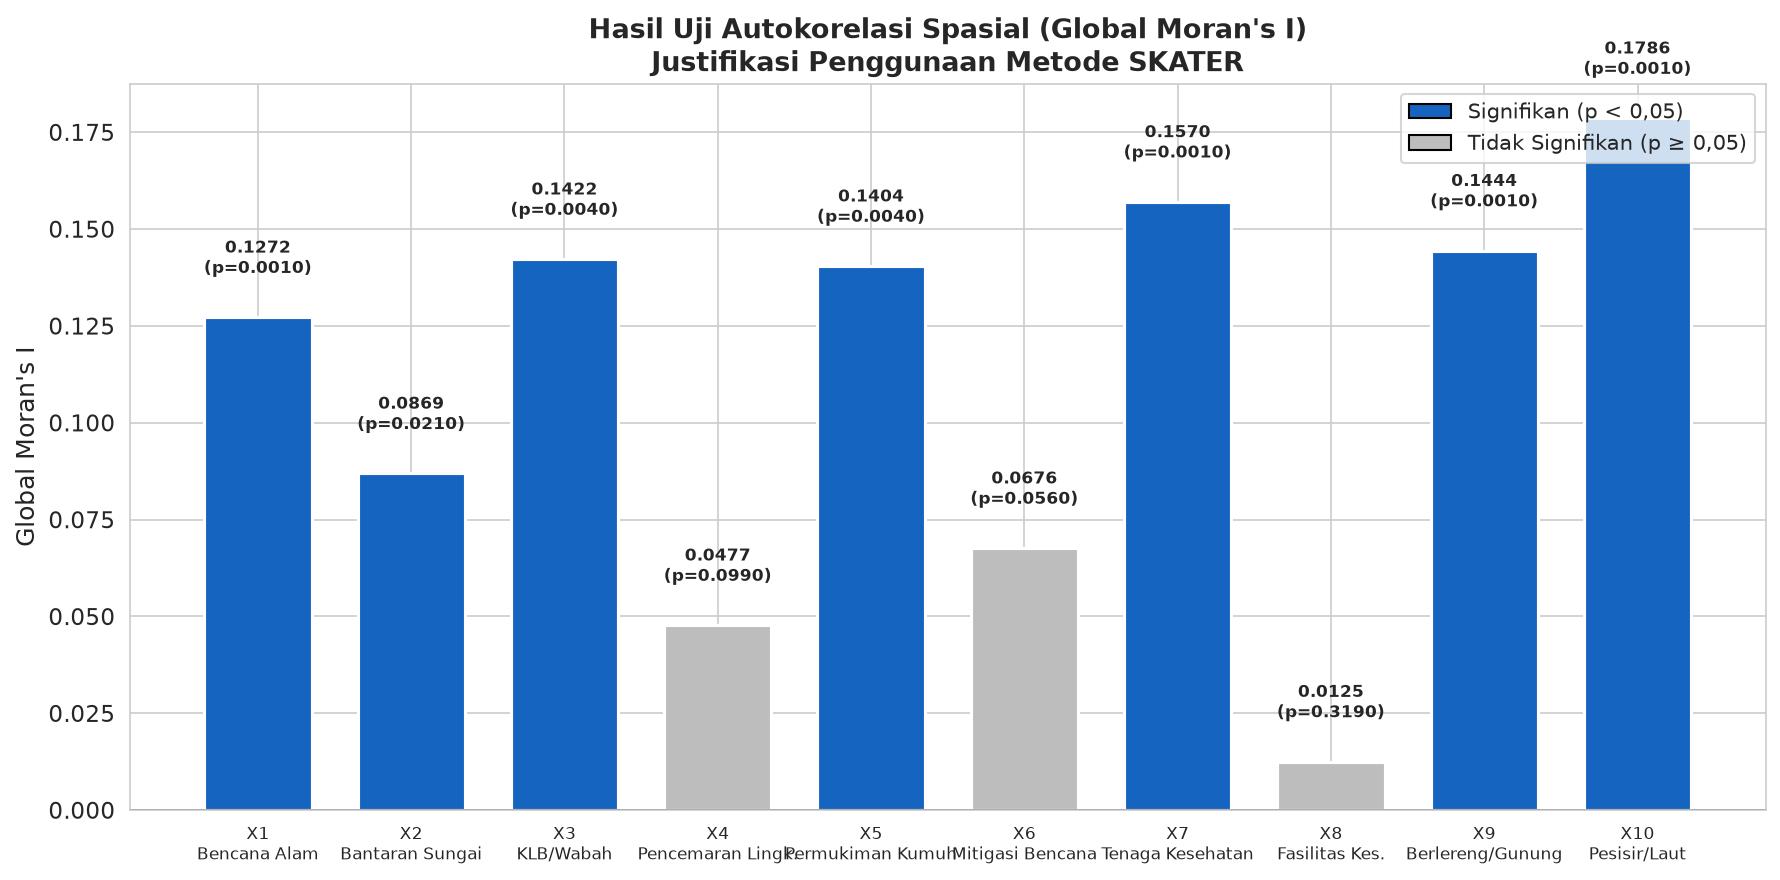

Gambar disimpan: uji_morans_i_barplot.png


In [12]:
# ============================================================
# VISUALISASI: Hasil Uji Global Moran's I
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

colors_moran = ['#1565C0' if r['p-value'] < 0.05 else '#BDBDBD' for r in moran_results]
morans_values = [r["Moran's I"] for r in moran_results]
var_names = [f"{r['Variabel']}\n{r['Deskripsi']}" for r in moran_results]

bars = ax.bar(range(len(ATTRS)), morans_values, color=colors_moran,
              edgecolor='white', linewidth=1.5, width=0.7)

# Tambahkan nilai di atas bar
for i, (bar, val, res) in enumerate(zip(bars, morans_values, moran_results)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}\n(p={res['p-value']:.4f})",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xticks(range(len(ATTRS)))
ax.set_xticklabels(var_names, fontsize=8, ha='center')
ax.set_ylabel("Global Moran's I", fontsize=12)
ax.set_title("Hasil Uji Autokorelasi Spasial (Global Moran's I)\n"
             "Justifikasi Penggunaan Metode SKATER",
             fontsize=13, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor='#1565C0', edgecolor='black', label='Signifikan (p < 0,05)'),
    Patch(facecolor='#BDBDBD', edgecolor='black', label='Tidak Signifikan (p ≥ 0,05)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/uji_morans_i_barplot.png')
plt.show()
print("Gambar disimpan: uji_morans_i_barplot.png")

## Tahap 5: Algoritma SKATER

### Deskripsi Metode

SKATER (*Spatial 'K'luster Analysis by Tree Edge Removal*) adalah metode klasterisasi spasial yang dikembangkan oleh Assunção et al. (2006). Metode ini menggabungkan informasi atribut dan spasial untuk membentuk region/klaster yang terdiri dari unit-unit bersebelahan secara geografis dan homogen secara karakteristik.

### Tahapan Algoritma SKATER

**Langkah 1: Konstruksi Graf Berbobot**  
Dari matriks pembobotan spasial **W**, dibentuk graf $G = (V, E)$ di mana:
- $V$ = himpunan kecamatan (node)
- $E$ = himpunan edge berdasarkan relasi ketetanggaan
- Bobot edge $d(i,j)$ = jarak Euclidean antara vektor atribut unit $i$ dan $j$

**Langkah 2: Pembentukan Minimum Spanning Tree (MST)**  
Dari graf berbobot, dibangun MST menggunakan algoritma Prim atau Kruskal. MST meminimumkan total bobot edge sambil menjaga keterhubungan semua node.

**Langkah 3: Pemotongan Edge (*Edge Removal*)**  
Untuk membentuk $k$ klaster, $(k-1)$ edge dipotong dari MST. Edge yang dipotong adalah edge yang jika dihilangkan menghasilkan pengurangan *total sum of squares* (TSS) internal terbesar.

### Syarat dan Asumsi

1. **Kontiguitas spasial (*Spatial contiguity*):** Klaster yang dihasilkan harus terdiri dari unit yang terhubung secara spasial.
2. **Homogenitas internal:** Unit dalam klaster yang sama harus memiliki kesamaan pada variabel atribut.
3. **Data numerik kontinu:** Variabel atribut harus berskala numerik (interval/rasio).
4. **Standardisasi:** Variabel harus distandardisasi agar memiliki bobot yang setara dalam perhitungan jarak (data sudah distandardisasi pada tahap preprocessing).
5. **Graf fully connected:** Semua unit harus terhubung dalam satu komponen (sudah dipenuhi di Tahap 4).

### Batasan Ukuran Minimum Klaster (*Floor Constraint*)

Dalam regionalisasi spasial berbasis SKATER, ketiadaan batasan ukuran region dapat memicu pemisahan klaster kerdil (*small cluster problem*) akibat keberadaan *spatial outliers* perkotaan (Assunção et al., 2006). Untuk menjamin keseimbangan wilayah dan penerapan kebijakan mitigasi bencana yang operasional, parameter  ditetapkan sebesar 10 kecamatan (~3,5% dari total wilayah) sebagai ambang batas minimum unit per klaster.


In [13]:
# ============================================================
# LANGKAH 1: VISUALISASI MINIMUM SPANNING TREE (MST)
# ============================================================

# Bangun graf berbobot dari ketetanggaan dan jarak atribut
X = gdf[ATTRS].values

G_weighted = nx.Graph()
for i in range(len(gdf)):
    G_weighted.add_node(i)

for i in range(len(gdf)):
    for j in w.neighbors[i]:
        if j > i:
            dist = np.sqrt(np.sum((X[i] - X[j])**2))
            G_weighted.add_edge(i, j, weight=dist)

# Bangun MST
mst = nx.minimum_spanning_tree(G_weighted)

print(f"Graf berbobot : {G_weighted.number_of_nodes()} nodes, {G_weighted.number_of_edges()} edges")
print(f"MST           : {mst.number_of_nodes()} nodes, {mst.number_of_edges()} edges")
print(f"Total bobot MST: {sum(d['weight'] for _, _, d in mst.edges(data=True)):.4f}")

Graf berbobot : 290 nodes, 725 edges
MST           : 290 nodes, 289 edges
Total bobot MST: 752.3900


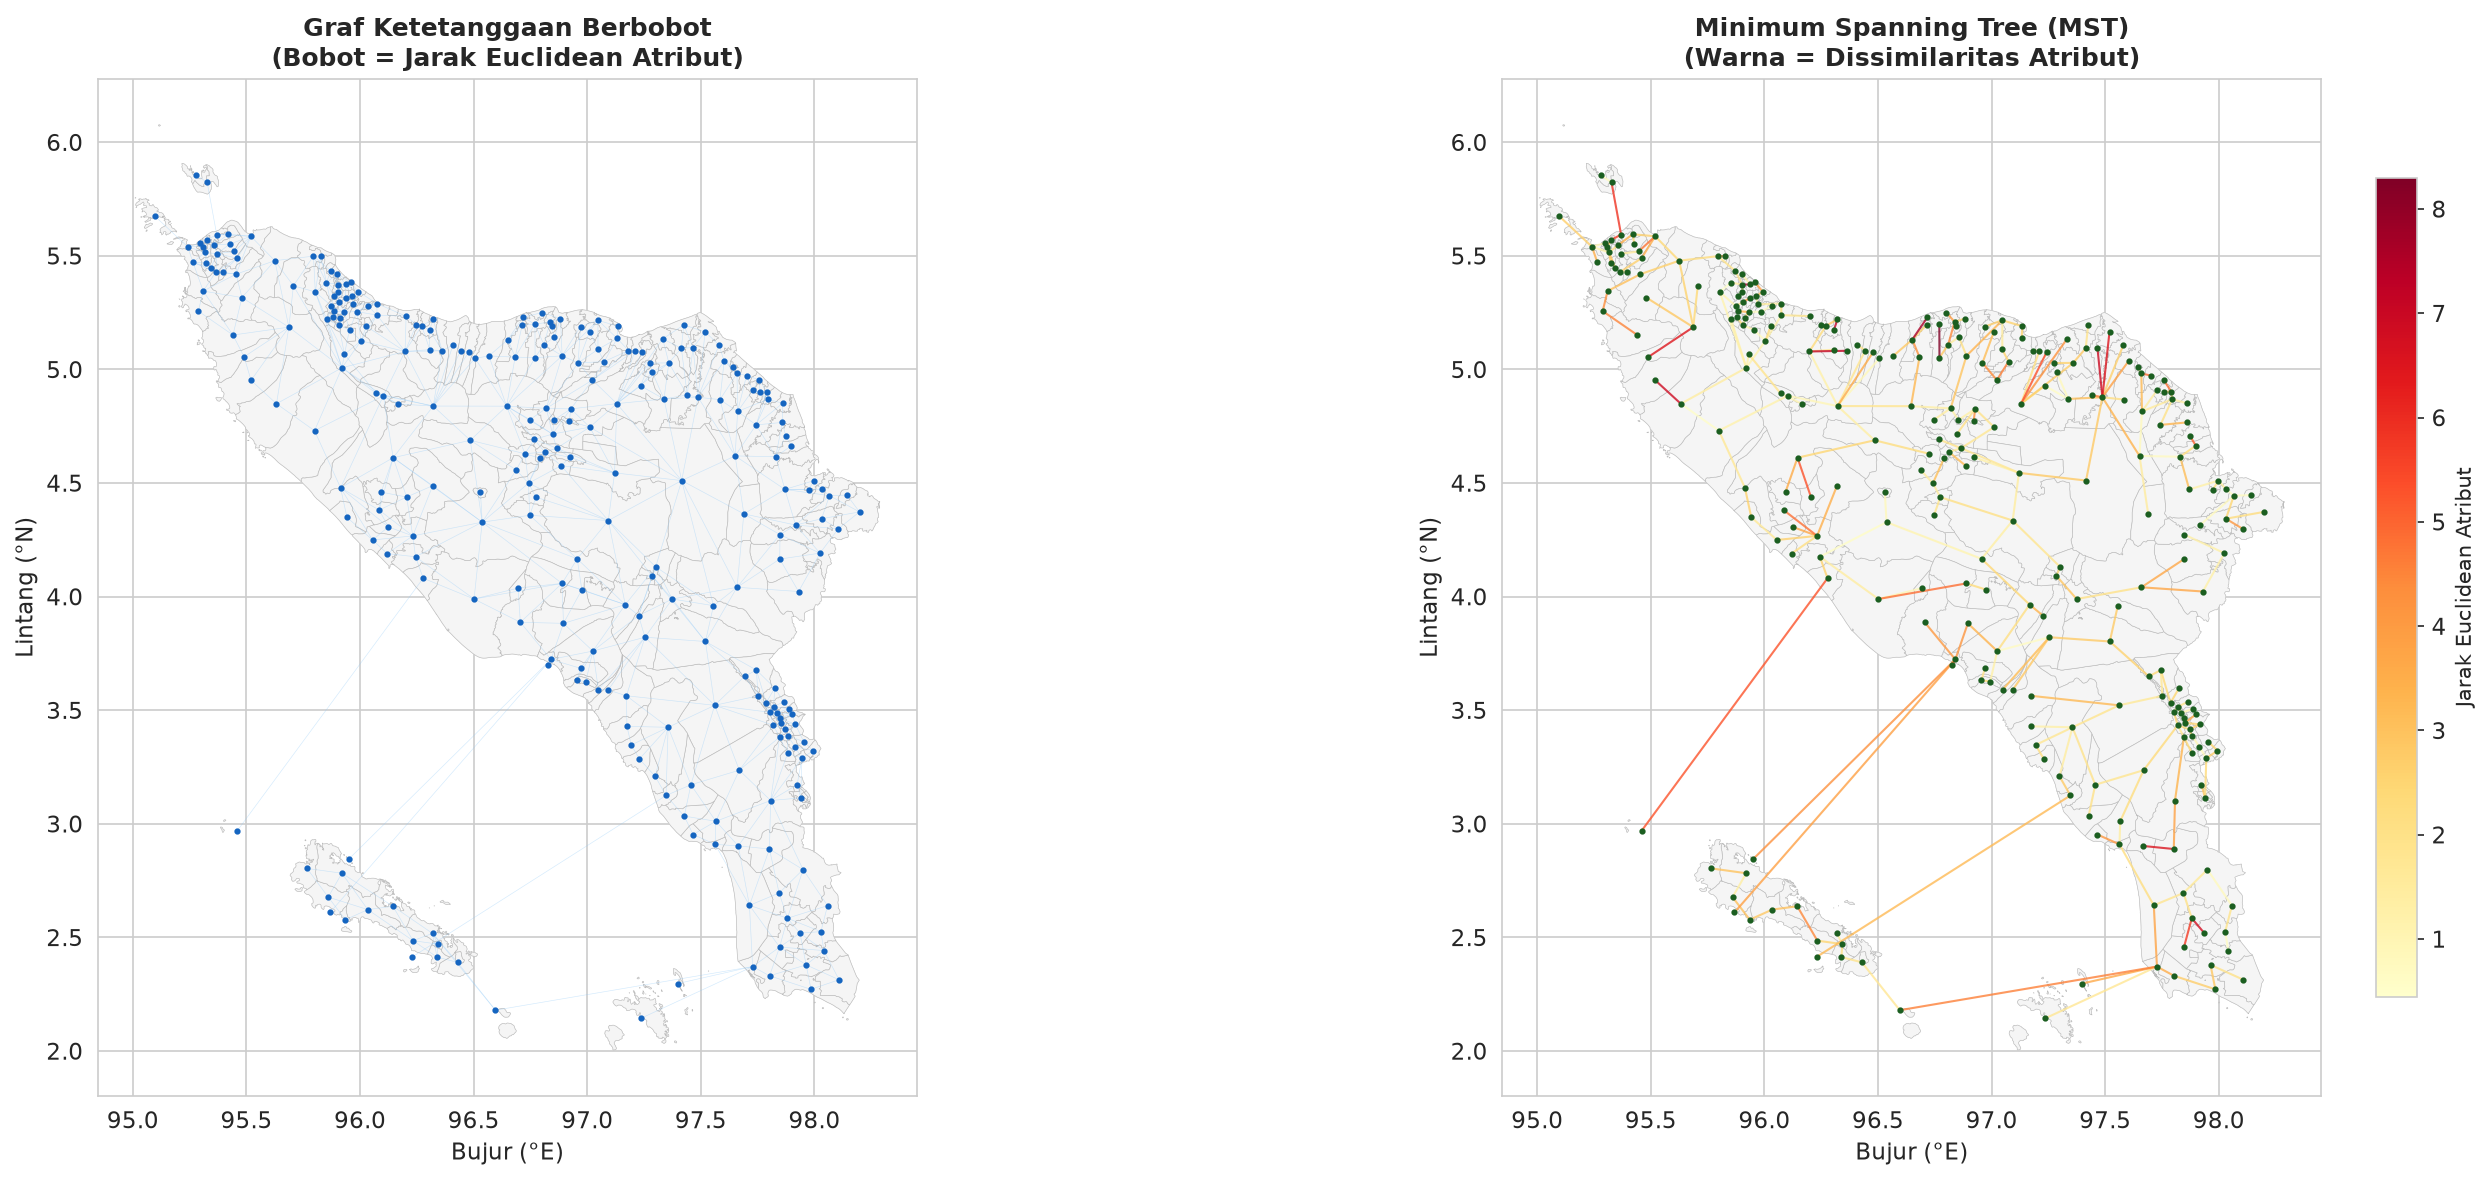

Gambar disimpan: 03_graf_dan_MST.png


In [14]:
# ============================================================
# VISUALISASI: Minimum Spanning Tree pada Peta
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel kiri: Graf ketetanggaan berbobot ---
ax1 = axes[0]
gdf_raw.plot(ax=ax1, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background
gdf.plot(ax=ax1, color='#F5F5F5', edgecolor='#BDBDBD', linewidth=0.3)
for i, j, d in G_weighted.edges(data=True):
    ax1.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
             color='#90CAF9', linewidth=0.3, alpha=0.4)
ax1.scatter(coords[:, 0], coords[:, 1], c='#1565C0', s=4, zorder=5)
ax1.set_title('Graf Ketetanggaan Berbobot\n(Bobot = Jarak Euclidean Atribut)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Bujur (°E)')
ax1.set_ylabel('Lintang (°N)')
ax1.set_aspect('equal')

# --- Panel kanan: Minimum Spanning Tree ---
ax2 = axes[1]
gdf_raw.plot(ax=ax2, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background
gdf.plot(ax=ax2, color='#F5F5F5', edgecolor='#BDBDBD', linewidth=0.3)
edge_weights = [d['weight'] for _, _, d in mst.edges(data=True)]
w_min, w_max = min(edge_weights), max(edge_weights)
cmap = plt.cm.YlOrRd
for i, j, d in mst.edges(data=True):
    norm_w = (d['weight'] - w_min) / (w_max - w_min)
    ax2.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
             color=cmap(norm_w), linewidth=1.0, alpha=0.8)
ax2.scatter(coords[:, 0], coords[:, 1], c='#1B5E20', s=4, zorder=5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=w_min, vmax=w_max))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.04)
cbar.set_label('Jarak Euclidean Atribut', fontsize=10)
ax2.set_title('Minimum Spanning Tree (MST)\n(Warna = Dissimilaritas Atribut)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Bujur (°E)')
ax2.set_ylabel('Lintang (°N)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_graf_dan_MST.png')
plt.show()
print("Gambar disimpan: 03_graf_dan_MST.png")

## Tahap 6: Penentuan Jumlah Klaster Optimal ($k$)

### Metode Scree Plot

Scree plot digunakan untuk mengevaluasi jumlah klaster optimal pada rentang $k \in \{2, 3, 4\}$. Metrik evaluasi yang digunakan:

1. **Silhouette Score (ASW):** Mengukur seberapa mirip suatu objek dengan klasternya sendiri dibandingkan klaster terdekat lainnya. Nilai berkisar $[-1, 1]$; semakin tinggi semakin baik (Rousseeuw, 1987).

2. **Davies-Bouldin Index (DBI):** Mengukur rasio rata-rata dispersi internal terhadap jarak antar centroid klaster. Nilai semakin **rendah** semakin baik (Davies & Bouldin, 1979).

3. **Calinski-Harabasz Index (CHI):** Rasio antara dispersi antar klaster (*between-cluster*) dan dispersi dalam klaster (*within-cluster*). Nilai semakin **tinggi** semakin baik (Caliński & Harabasz, 1974).

4. **TSS/Total (*Total Sum of Squares Ratio*):** Rasio antara TSS within-cluster terhadap total TSS. Nilai semakin **rendah** menunjukkan klaster yang lebih homogen.

5. **Dunn Index:** Rasio antara jarak minimum antar klaster dan diameter maksimum dalam klaster. Nilai semakin **tinggi** semakin baik.

In [15]:
# ============================================================
# FUNGSI EVALUASI KLASTER
# ============================================================

def compute_tss_ratio(X, labels):
    """
    Menghitung rasio TSS within-cluster / TSS total.
    
    TSS_total = sum((x_i - x_mean)^2)
    TSS_within = sum_k sum_{i in C_k} (x_i - x_k_mean)^2
    Rasio = TSS_within / TSS_total
    """
    total_mean = X.mean(axis=0)
    tss_total = np.sum((X - total_mean)**2)
    
    tss_within = 0
    for k in np.unique(labels):
        cluster_data = X[labels == k]
        cluster_mean = cluster_data.mean(axis=0)
        tss_within += np.sum((cluster_data - cluster_mean)**2)
    
    return tss_within / tss_total


def compute_dunn_index(X, labels):
    """
    Menghitung Dunn Index.
    
    Dunn = min(d(C_i, C_j)) / max(diam(C_k))
    di mana:
    - d(C_i, C_j) = jarak minimum antara titik di klaster i dan j
    - diam(C_k) = jarak maksimum antara dua titik dalam klaster k
    """
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters < 2:
        return 0.0
    
    # Diameter tiap klaster
    max_diameter = 0
    for k in unique_labels:
        cluster_data = X[labels == k]
        if len(cluster_data) > 1:
            dists = pdist(cluster_data)
            max_diameter = max(max_diameter, np.max(dists))
    
    if max_diameter == 0:
        return 0.0
    
    # Jarak minimum antar klaster
    min_inter = float('inf')
    for i_idx in range(n_clusters):
        for j_idx in range(i_idx + 1, n_clusters):
            ci = X[labels == unique_labels[i_idx]]
            cj = X[labels == unique_labels[j_idx]]
            for a in ci:
                for b in cj:
                    d = np.sqrt(np.sum((a - b)**2))
                    min_inter = min(min_inter, d)
    
    return min_inter / max_diameter


print("Fungsi evaluasi klaster telah didefinisikan.")

Fungsi evaluasi klaster telah didefinisikan.


In [16]:
# ============================================================
# MENJALANKAN SKATER UNTUK k = 2, 3, 4
# ============================================================
results = {}
X_data = gdf[ATTRS].values
for k in K_RANGE:
    print(f"\n{'='*50}")
    print(f"Menjalankan SKATER dengan k = {k}")
    print(f"{'='*50}")
    
    # Jalankan SKATER
    model = Skater(
        gdf, w, ATTRS,
        n_clusters=k,
        floor=FLOOR_SIZE,
        trace=False
    )
    model.solve()
    
    labels = model.labels_
    unique_labels = np.unique(labels)
    
    # Hitung metrik evaluasi
    asw = silhouette_score(X_data, labels)
    dbi = davies_bouldin_score(X_data, labels)
    chi = calinski_harabasz_score(X_data, labels)
    tss_ratio = compute_tss_ratio(X_data, labels)
    dunn = compute_dunn_index(X_data, labels)
    
    results[k] = {
        'model': model,
        'labels': labels,
        'n_clusters_actual': len(unique_labels),
        'ASW': asw,
        'DBI': dbi,
        'CHI': chi,
        'TSS_ratio': tss_ratio,
        'Dunn': dunn,
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    }
    
    print(f"  Klaster aktual   : {len(unique_labels)}")
    print(f"  Ukuran klaster   : {results[k]['cluster_sizes']}")
    print(f"  Silhouette (ASW) : {asw:.4f}")
    print(f"  Davies-Bouldin   : {dbi:.4f}")
    print(f"  Calinski-Harabasz: {chi:.4f}")
    print(f"  TSS/Total        : {tss_ratio:.4f}")
    print(f"  Dunn Index       : {dunn:.4f}")



Menjalankan SKATER dengan k = 2
  Klaster aktual   : 2
  Ukuran klaster   : {0: 106, 1: 184}
  Silhouette (ASW) : 0.0165
  Davies-Bouldin   : 5.3953
  Calinski-Harabasz: 7.0048
  TSS/Total        : 0.9763
  Dunn Index       : 0.0000

Menjalankan SKATER dengan k = 3


  Klaster aktual   : 3
  Ukuran klaster   : {0: 106, 1: 166, 2: 18}
  Silhouette (ASW) : 0.0151
  Davies-Bouldin   : 4.4532
  Calinski-Harabasz: 8.0020
  TSS/Total        : 0.9472
  Dunn Index       : 0.0000

Menjalankan SKATER dengan k = 4


  Klaster aktual   : 4
  Ukuran klaster   : {0: 20, 1: 86, 2: 166, 3: 18}
  Silhouette (ASW) : -0.0058
  Davies-Bouldin   : 3.9195
  Calinski-Harabasz: 7.6367
  TSS/Total        : 0.9258
  Dunn Index       : 0.0000


In [17]:
# ============================================================
# TABEL EVALUASI KLASTER
# ============================================================

eval_df = pd.DataFrame({
    'Metode': ['SKATER'] * len(K_RANGE),
    'k': K_RANGE,
    'Silhouette Score (ASW)': [results[k]['ASW'] for k in K_RANGE],
    'Davies-Bouldin Index (DBI)': [results[k]['DBI'] for k in K_RANGE],
    'Calinski-Harabasz Index (CHI)': [results[k]['CHI'] for k in K_RANGE],
    'TSS / Total': [results[k]['TSS_ratio'] for k in K_RANGE],
    'Dunn Index': [results[k]['Dunn'] for k in K_RANGE]
})

print("\n" + "=" * 100)
print("TABEL EVALUASI KLASTER SKATER")
print("=" * 100)
display(eval_df.round(4))

# Simpan tabel ke Excel
eval_df.to_excel(f'{OUTPUT_DIR}/tabel_evaluasi_klaster.xlsx', index=False)
print(f"\nTabel disimpan: tabel_evaluasi_klaster.xlsx")


TABEL EVALUASI KLASTER SKATER


,Metode,k,Silhouette Score (ASW),Davies-Bouldin Index (DBI),Calinski-Harabasz Index (CHI),TSS / Total,Dunn Index
0,SKATER,2,0.0165,5.3953,7.0048,0.9763,0.0
1,SKATER,3,0.0151,4.4532,8.0020,0.9472,0.0
2,SKATER,4,-0.0058,3.9195,7.6367,0.9258,0.0



Tabel disimpan: tabel_evaluasi_klaster.xlsx


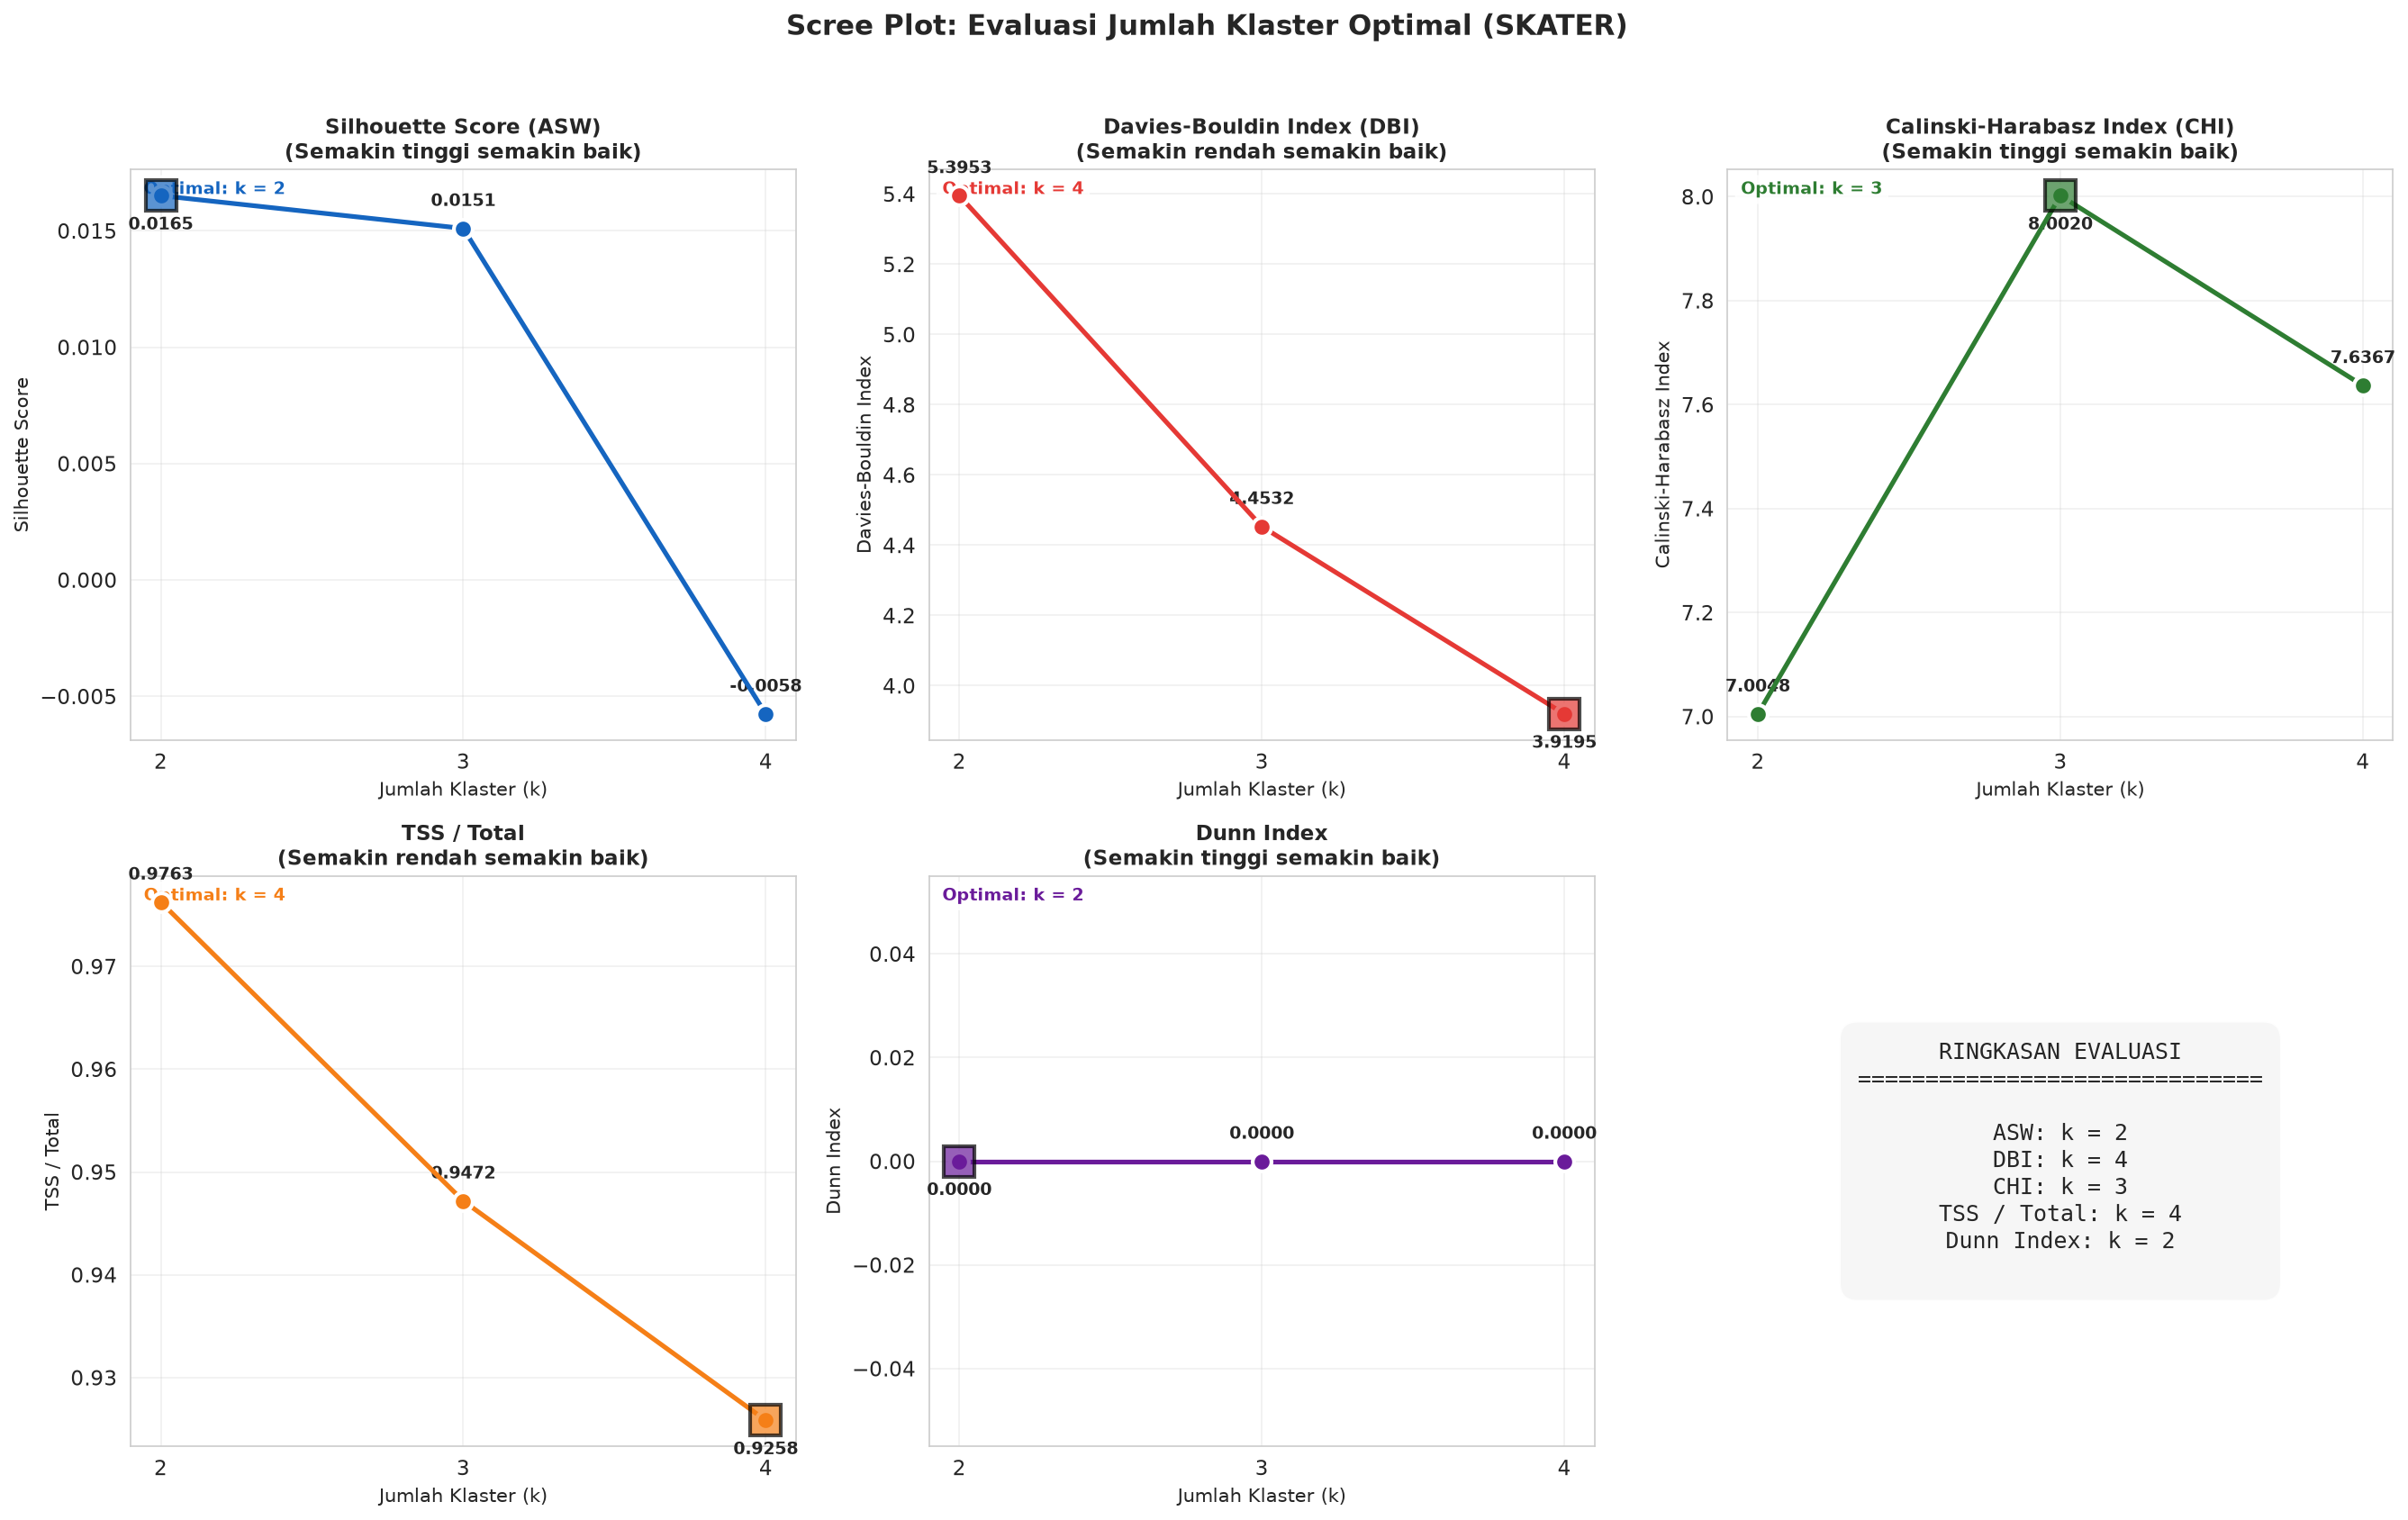

Gambar disimpan: 04_scree_plot_evaluasi_klaster.png


In [18]:
# ============================================================
# VISUALISASI: Scree Plot (5 Metrik Evaluasi)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

metrics = [
    ('ASW', 'Silhouette Score (ASW)', 'Semakin tinggi semakin baik', '#1565C0', 'max'),
    ('DBI', 'Davies-Bouldin Index (DBI)', 'Semakin rendah semakin baik', '#E53935', 'min'),
    ('CHI', 'Calinski-Harabasz Index (CHI)', 'Semakin tinggi semakin baik', '#2E7D32', 'max'),
    ('TSS_ratio', 'TSS / Total', 'Semakin rendah semakin baik', '#F57F17', 'min'),
    ('Dunn', 'Dunn Index', 'Semakin tinggi semakin baik', '#6A1B9A', 'max'),
]

for idx, (key, title, subtitle, color, direction) in enumerate(metrics):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    
    values = [results[k][key] for k in K_RANGE]
    
    ax.plot(K_RANGE, values, 'o-', color=color, linewidth=2.5, markersize=10,
            markeredgecolor='white', markeredgewidth=2, zorder=5)
    
    # Highlight optimal
    if direction == 'max':
        opt_idx = np.argmax(values)
    else:
        opt_idx = np.argmin(values)
    
    ax.plot(K_RANGE[opt_idx], values[opt_idx], 's', color=color, markersize=16,
            markeredgecolor='black', markeredgewidth=2, zorder=6, alpha=0.7)
    
    # Anotasi nilai
    for i, (kv, vv) in enumerate(zip(K_RANGE, values)):
        offset = 12 if i != opt_idx else -18
        ax.annotate(f'{vv:.4f}', (kv, vv), textcoords='offset points',
                    xytext=(0, offset), ha='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{title}\n({subtitle})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Klaster (k)', fontsize=10)
    ax.set_ylabel(title.split('(')[0].strip(), fontsize=10)
    ax.set_xticks(K_RANGE)
    ax.grid(True, alpha=0.3)
    
    ax.text(0.02, 0.98, f'Optimal: k = {K_RANGE[opt_idx]}',
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            verticalalignment='top', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Ringkasan di subplot kosong
axes[1, 2].axis('off')
summary_text = "RINGKASAN EVALUASI\n" + "=" * 30 + "\n\n"
for key, title, subtitle, color, direction in metrics:
    values = [results[k][key] for k in K_RANGE]
    if direction == 'max':
        opt_k = K_RANGE[np.argmax(values)]
    else:
        opt_k = K_RANGE[np.argmin(values)]
    short_name = title.split('(')[1].replace(')', '') if '(' in title else title
    summary_text += f"{short_name}: k = {opt_k}\n"

axes[1, 2].text(0.5, 0.5, summary_text, transform=axes[1, 2].transAxes,
                fontsize=12, verticalalignment='center', horizontalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#F5F5F5', alpha=0.9))

fig.suptitle('Scree Plot: Evaluasi Jumlah Klaster Optimal (SKATER)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_scree_plot_evaluasi_klaster.png')
plt.show()
print("Gambar disimpan: 04_scree_plot_evaluasi_klaster.png")

In [19]:
# ============================================================
# PENENTUAN k OPTIMAL
# ============================================================

k_votes = {k: 0 for k in K_RANGE}

for key, _, _, _, direction in [('ASW','','','','max'), ('DBI','','','','min'), 
                                 ('CHI','','','','max'), ('TSS_ratio','','','','min'),
                                 ('Dunn','','','','max')]:
    values = [results[k][key] for k in K_RANGE]
    if direction == 'max':
        k_votes[K_RANGE[np.argmax(values)]] += 1
    else:
        k_votes[K_RANGE[np.argmin(values)]] += 1

print("Voting Penentuan k Optimal:")
print("=" * 40)
for k, vote in sorted(k_votes.items()):
    print(f"  k = {k}: {vote}/5 metrik mendukung")

BEST_K = max(k_votes, key=k_votes.get)
print(f"\n>>> k OPTIMAL = {BEST_K} <<<")
print(f"\nKlaster optimal dipilih berdasarkan mayoritas metrik evaluasi.")

Voting Penentuan k Optimal:
  k = 2: 2/5 metrik mendukung
  k = 3: 1/5 metrik mendukung
  k = 4: 2/5 metrik mendukung

>>> k OPTIMAL = 2 <<<

Klaster optimal dipilih berdasarkan mayoritas metrik evaluasi.


## Tahap 7: Hasil Klasterisasi dengan $k$ Optimal

Setelah penentuan jumlah klaster optimal, berikut adalah hasil klasterisasi spasial SKATER beserta interpretasinya.

In [20]:
# ============================================================
# HASIL KLASTERISASI k OPTIMAL
# ============================================================

best_labels = results[BEST_K]['labels']
gdf['Cluster'] = best_labels

print(f"\nHasil Klasterisasi SKATER (k = {BEST_K})")
print("=" * 60)

cluster_dist = gdf['Cluster'].value_counts().sort_index()
for c in cluster_dist.index:
    kabs = gdf[gdf['Cluster'] == c]['Kabupaten'].unique()
    print(f"\nKlaster {c+1}: {cluster_dist[c]} kecamatan")
    print(f"  Kabupaten: {', '.join(sorted(kabs))}")


Hasil Klasterisasi SKATER (k = 2)

Klaster 1: 106 kecamatan
  Kabupaten: Aceh Barat, Aceh Barat Daya, Aceh Besar, Aceh Jaya, Aceh Selatan, Aceh Singkil, Aceh Tenggara, Aceh Utara, Bener Meriah, Bireuen, Kota Subulussalam, Nagan Raya, Pidie, Simeulue

Klaster 2: 184 kecamatan
  Kabupaten: Aceh Barat, Aceh Barat Daya, Aceh Besar, Aceh Jaya, Aceh Selatan, Aceh Tamiang, Aceh Tengah, Aceh Tenggara, Aceh Timur, Aceh Utara, Bener Meriah, Bireuen, Gayo Lues, Kota Banda Aceh, Kota Langsa, Kota Lhokseumawe, Kota Sabang, Kota Subulussalam, Nagan Raya, Pidie, Pidie Jaya


In [21]:
# ============================================================
# RATA-RATA VARIABEL PER KLASTER
# ============================================================

print(f"\nRata-rata Variabel per Klaster (k = {BEST_K}):")
print("=" * 80)

means_table = gdf.groupby('Cluster')[ATTRS].mean().round(4)
means_table.index = [f'Klaster {i+1}' for i in means_table.index]
display(means_table)

means_table.to_excel(f'{OUTPUT_DIR}/profil_klaster_rata_rata.xlsx')
print(f"\nTabel disimpan: profil_klaster_rata_rata.xlsx")


Rata-rata Variabel per Klaster (k = 2):


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
Klaster 1,0.1742,-0.2124,0.0513,-0.0863,-0.1696,-0.1561,-0.3751,-0.0664,-0.2589,0.2477
Klaster 2,-0.1004,0.1224,-0.0295,0.0497,0.0977,0.0899,0.2161,0.0383,0.1491,-0.1427



Tabel disimpan: profil_klaster_rata_rata.xlsx


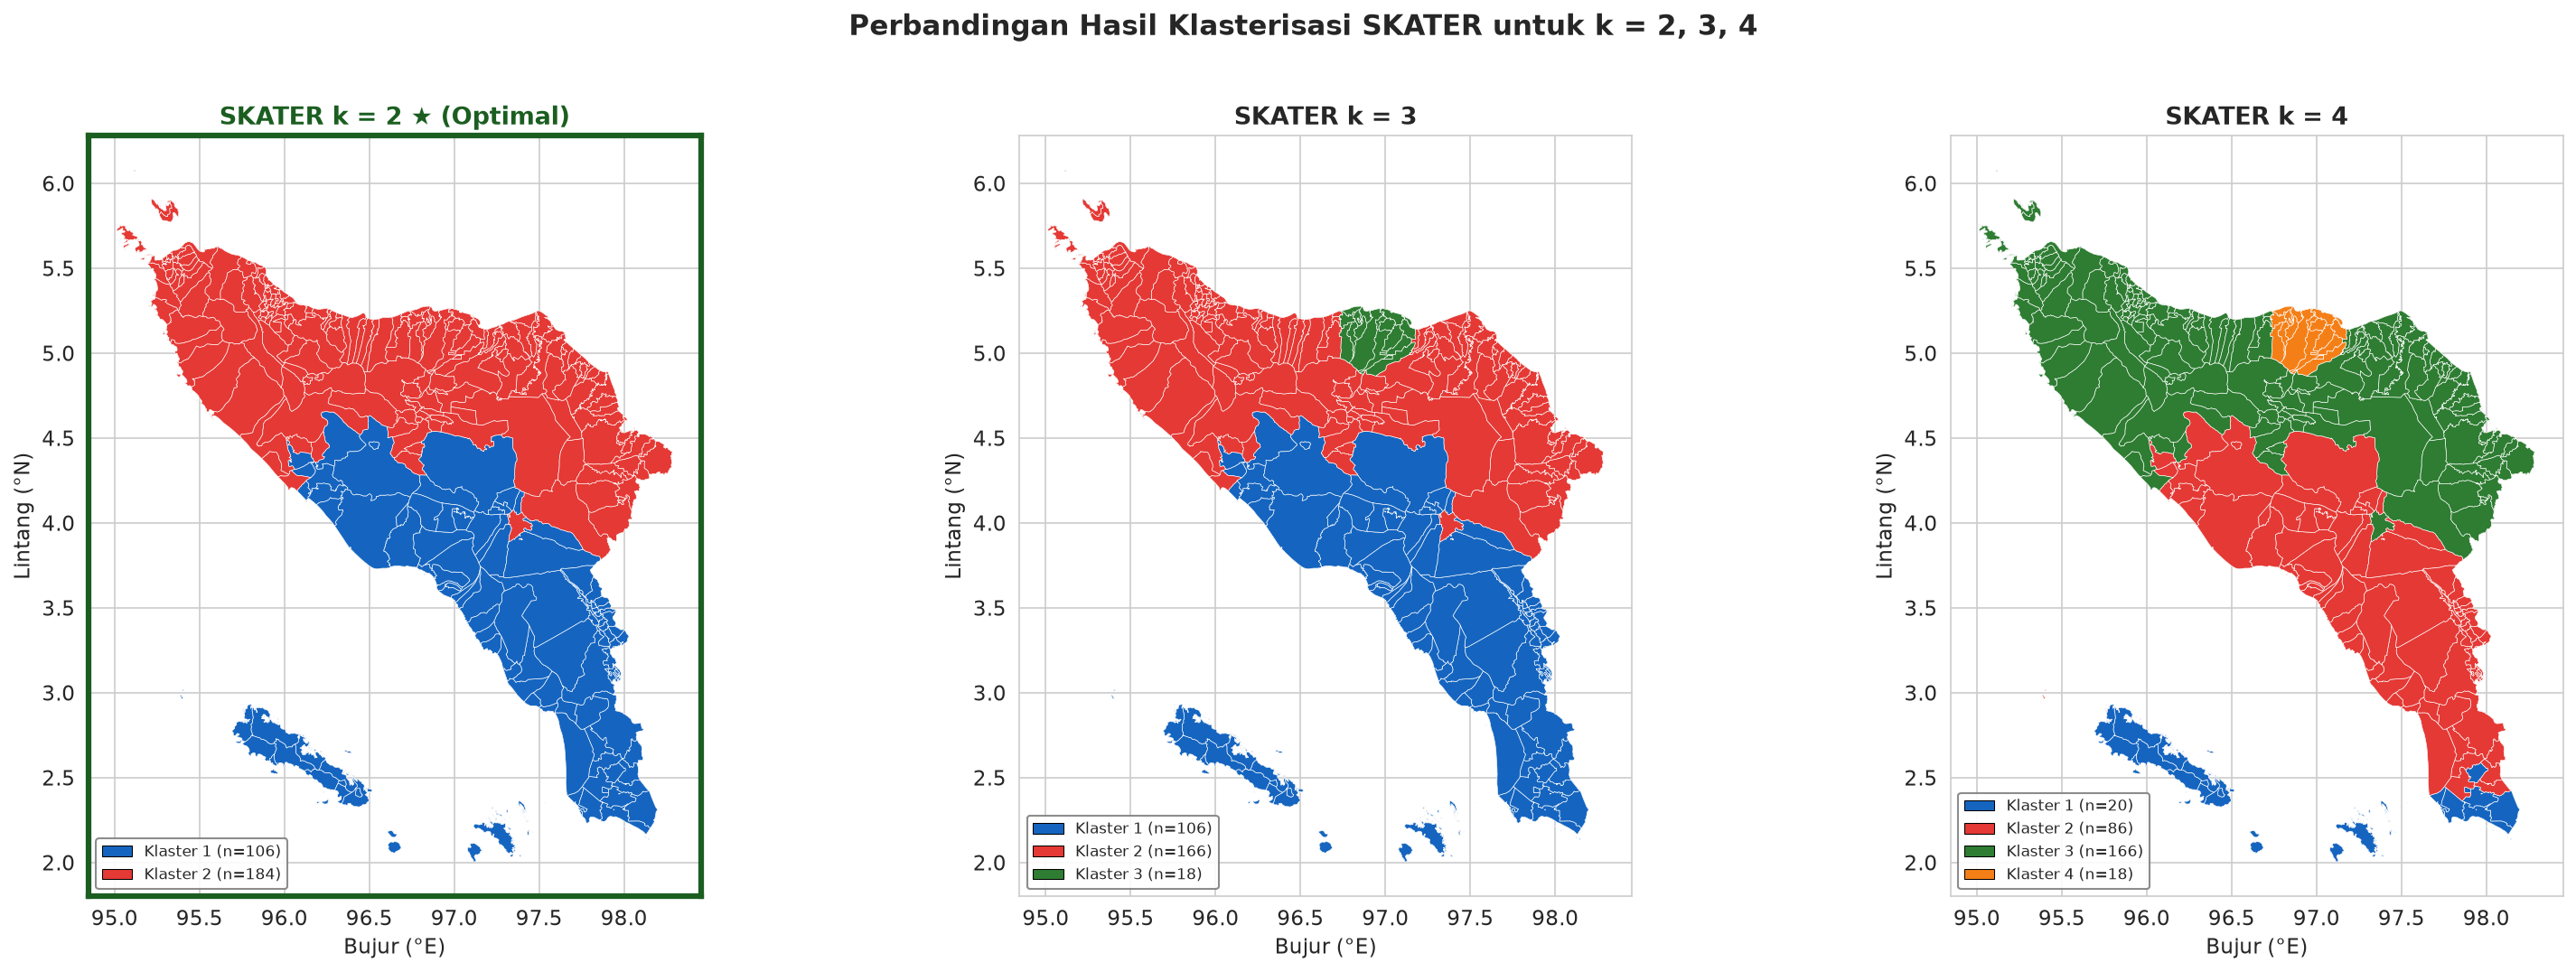

Gambar disimpan: 05_peta_klasterisasi_perbandingan.png


In [22]:
# ============================================================
# VISUALISASI: Peta Klasterisasi SKATER untuk SEMUA k
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

cluster_colors_all = [
    ['#1565C0', '#E53935'],
    ['#1565C0', '#E53935', '#2E7D32'],
    ['#1565C0', '#E53935', '#2E7D32', '#F57F17'],
]

for idx, k in enumerate(K_RANGE):
    ax = axes[idx]
    labels_k = results[k]['labels']
    gdf_temp = gdf.copy()
    gdf_temp['Cluster_k'] = labels_k
    
    unique_clusters = sorted(np.unique(labels_k))
    colors = cluster_colors_all[idx]
    cmap_custom = mcolors.ListedColormap(colors[:len(unique_clusters)])
    
    gdf_raw.plot(ax=ax, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background: semua 358 geometri
    gdf_temp.plot(column='Cluster_k', ax=ax, cmap=cmap_custom,
                  edgecolor='white', linewidth=0.3, legend=False)
    
    legend_elements = [
        Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5,
              label=f'Klaster {c+1} (n={np.sum(labels_k == c)})')
        for i, c in enumerate(unique_clusters)
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=8,
              framealpha=0.9, edgecolor='gray')
    
    if k == BEST_K:
        ax.set_title(f'SKATER k = {k} ★ (Optimal)', fontsize=13, fontweight='bold',
                     color='#1B5E20')
        for spine in ax.spines.values():
            spine.set_edgecolor('#1B5E20')
            spine.set_linewidth(3)
    else:
        ax.set_title(f'SKATER k = {k}', fontsize=13, fontweight='bold')
    
    ax.set_xlabel('Bujur (°E)')
    ax.set_ylabel('Lintang (°N)')
    ax.set_aspect('equal')

fig.suptitle('Perbandingan Hasil Klasterisasi SKATER untuk k = 2, 3, 4',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_peta_klasterisasi_perbandingan.png')
plt.show()
print("Gambar disimpan: 05_peta_klasterisasi_perbandingan.png")

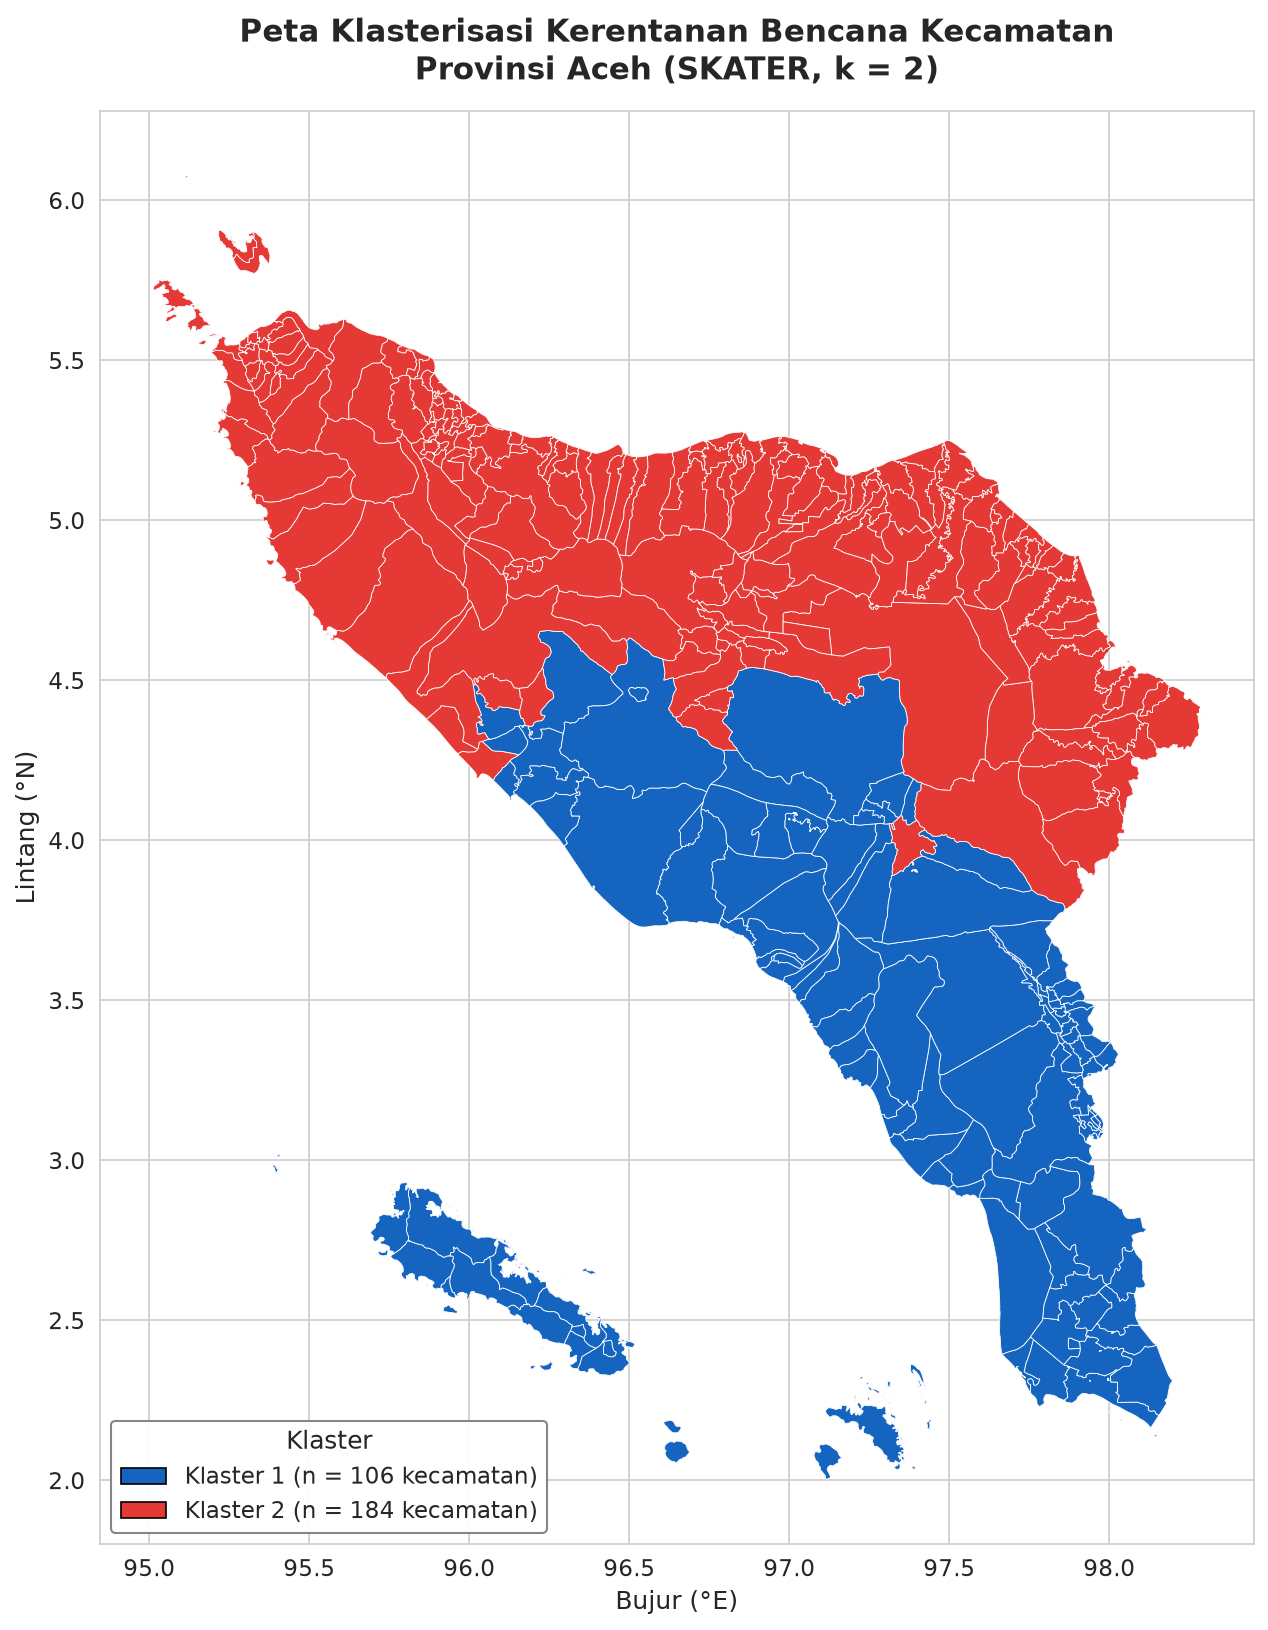

Gambar disimpan: 06_peta_klasterisasi_optimal.png


In [23]:
# ============================================================
# VISUALISASI: Peta Klasterisasi k Optimal (Detail)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

unique_clusters = sorted(np.unique(best_labels))
n_clusters = len(unique_clusters)
colors_used = PREMIUM_COLORS[:n_clusters]
cmap_best = mcolors.ListedColormap(colors_used)

gdf_raw.plot(ax=ax, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background: semua 358 geometri
gdf.plot(column='Cluster', ax=ax, cmap=cmap_best,
         edgecolor='white', linewidth=0.4, legend=False)

legend_elements = [
    Patch(facecolor=colors_used[i], edgecolor='black', linewidth=0.8,
          label=f'Klaster {c+1} (n = {np.sum(best_labels == c)} kecamatan)')
    for i, c in enumerate(unique_clusters)
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11,
          framealpha=0.95, edgecolor='gray', title='Klaster',
          title_fontsize=12)

ax.set_title(f'Peta Klasterisasi Kerentanan Bencana Kecamatan\n'
             f'Provinsi Aceh (SKATER, k = {BEST_K})',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Bujur (°E)', fontsize=12)
ax.set_ylabel('Lintang (°N)', fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_peta_klasterisasi_optimal.png')
plt.show()
print("Gambar disimpan: 06_peta_klasterisasi_optimal.png")

## Tahap 8: Interpretasi dan Profiling Klaster

Pada tahap ini, dilakukan karakterisasi setiap klaster berdasarkan rata-rata variabel kerentanan bencana. Interpretasi didasarkan pada komponen-komponen:
1. **Keterpaparan Bencana** (X1, X2)
2. **Kerentanan Lingkungan & Sosial** (X3, X4, X5)
3. **Kapasitas Mitigasi & Respons** (X6, X7, X8)
4. **Faktor Geografis Inheren** (X9, X10)

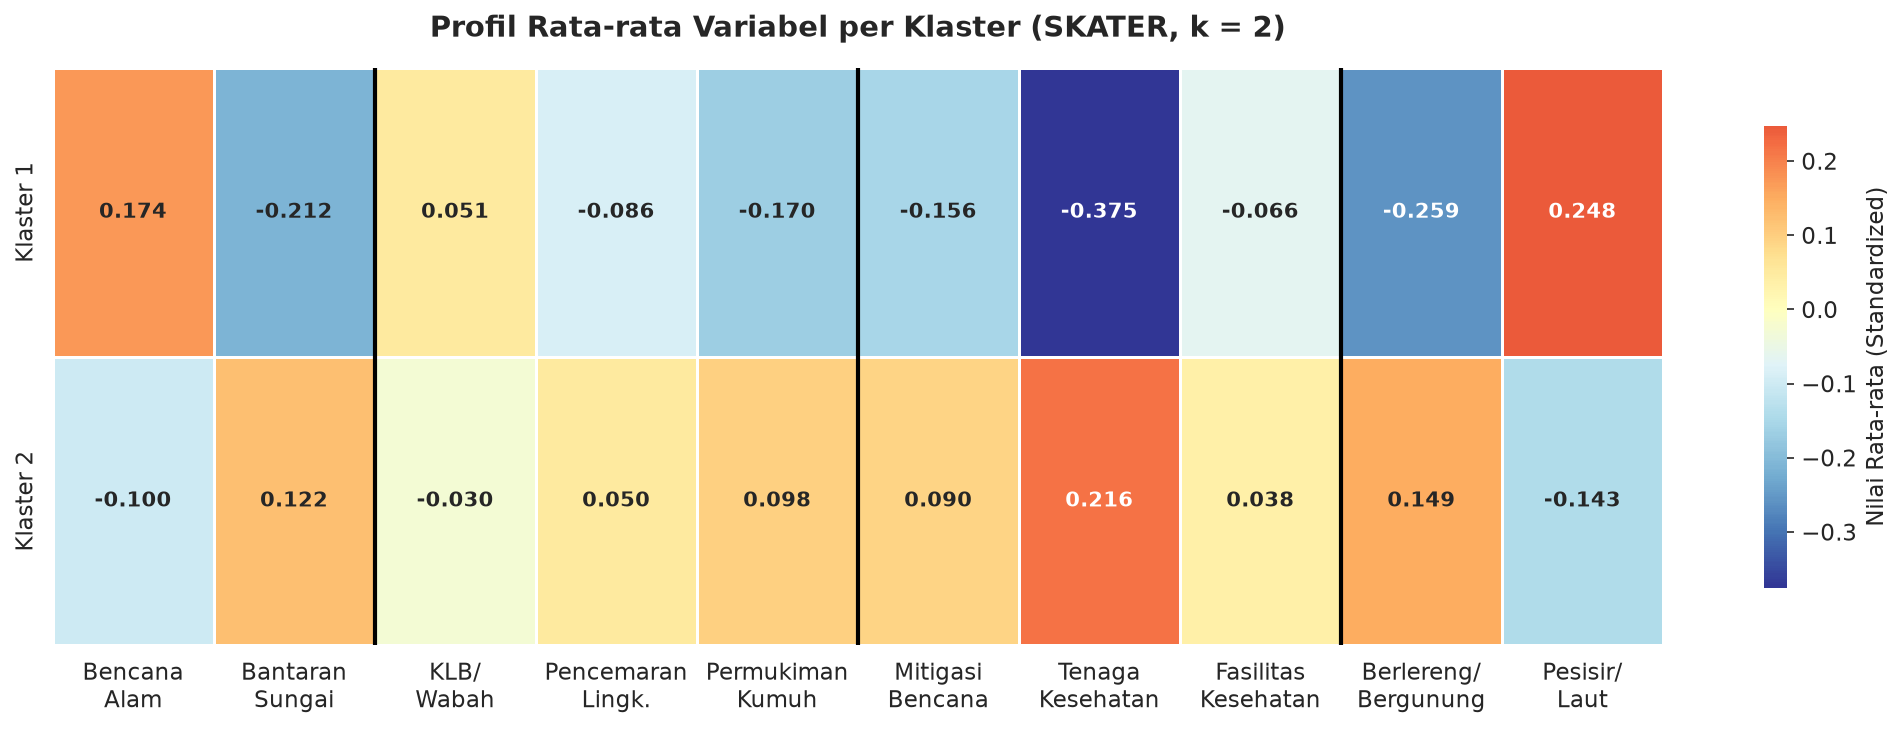

Gambar disimpan: 07_heatmap_profil_klaster.png


In [24]:
# ============================================================
# VISUALISASI: Heatmap Profil Klaster
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

means_data = gdf.groupby('Cluster')[ATTRS].mean()
means_data.index = [f'Klaster {i+1}' for i in means_data.index]

display_cols = {
    'X1': 'Bencana\nAlam', 'X2': 'Bantaran\nSungai', 'X3': 'KLB/\nWabah',
    'X4': 'Pencemaran\nLingk.', 'X5': 'Permukiman\nKumuh', 'X6': 'Mitigasi\nBencana',
    'X7': 'Tenaga\nKesehatan', 'X8': 'Fasilitas\nKesehatan',
    'X9': 'Berlereng/\nBergunung', 'X10': 'Pesisir/\nLaut'
}
means_display = means_data.rename(columns=display_cols)

sns.heatmap(
    means_display, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Nilai Rata-rata (Standardized)', 'shrink': 0.8},
    annot_kws={'fontsize': 10, 'fontweight': 'bold'}
)

ax.set_title(f'Profil Rata-rata Variabel per Klaster (SKATER, k = {BEST_K})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.axvline(x=2, color='black', linewidth=2)
ax.axvline(x=5, color='black', linewidth=2)
ax.axvline(x=8, color='black', linewidth=2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_heatmap_profil_klaster.png')
plt.show()
print("Gambar disimpan: 07_heatmap_profil_klaster.png")

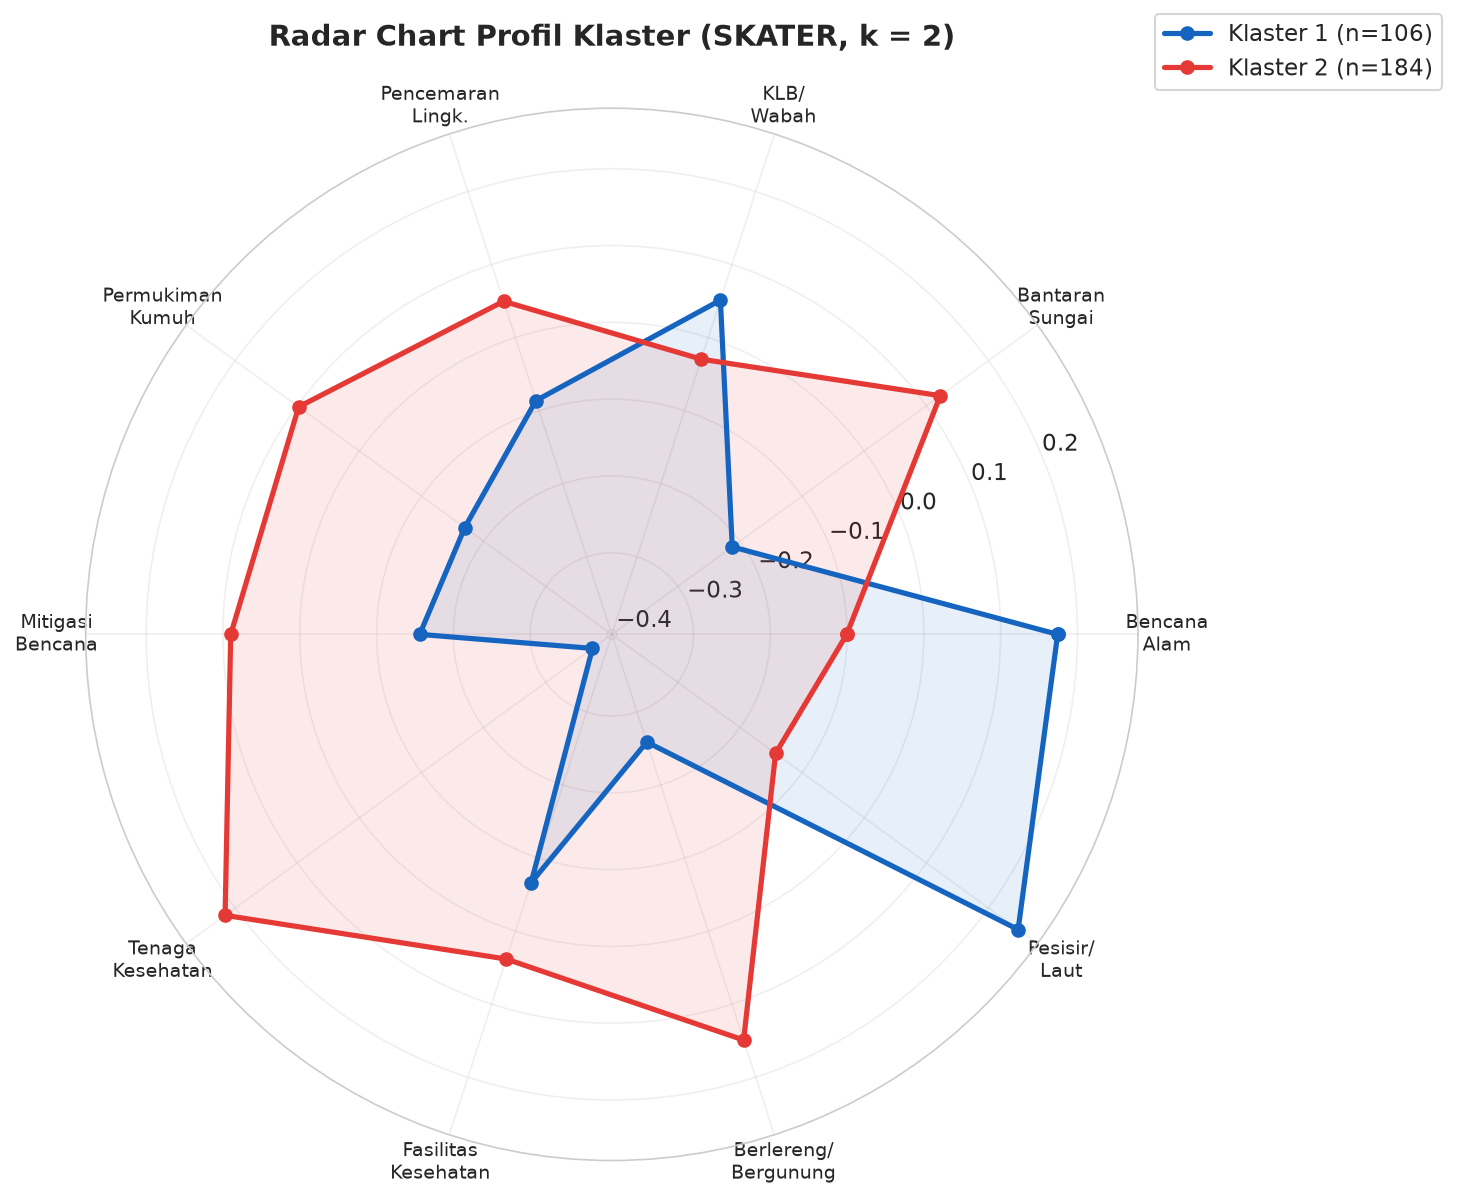

Gambar disimpan: 08_radar_chart_profil_klaster.png


In [25]:
# ============================================================
# VISUALISASI: Radar Chart / Spider Plot per Klaster
# ============================================================

means_data = gdf.groupby('Cluster')[ATTRS].mean()
cat_labels = [
    'Bencana\nAlam', 'Bantaran\nSungai', 'KLB/\nWabah',
    'Pencemaran\nLingk.', 'Permukiman\nKumuh', 'Mitigasi\nBencana',
    'Tenaga\nKesehatan', 'Fasilitas\nKesehatan', 'Berlereng/\nBergunung',
    'Pesisir/\nLaut'
]

N = len(ATTRS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cluster_id in sorted(means_data.index):
    values = means_data.loc[cluster_id, ATTRS].values.tolist()
    values += values[:1]
    color = PREMIUM_COLORS[cluster_id]
    n_kec = np.sum(best_labels == cluster_id)
    ax.plot(angles, values, 'o-', linewidth=2.5,
            label=f'Klaster {cluster_id+1} (n={n_kec})',
            color=color, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cat_labels, fontsize=9)
ax.set_title(f'Radar Chart Profil Klaster (SKATER, k = {BEST_K})',
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_radar_chart_profil_klaster.png')
plt.show()
print("Gambar disimpan: 08_radar_chart_profil_klaster.png")

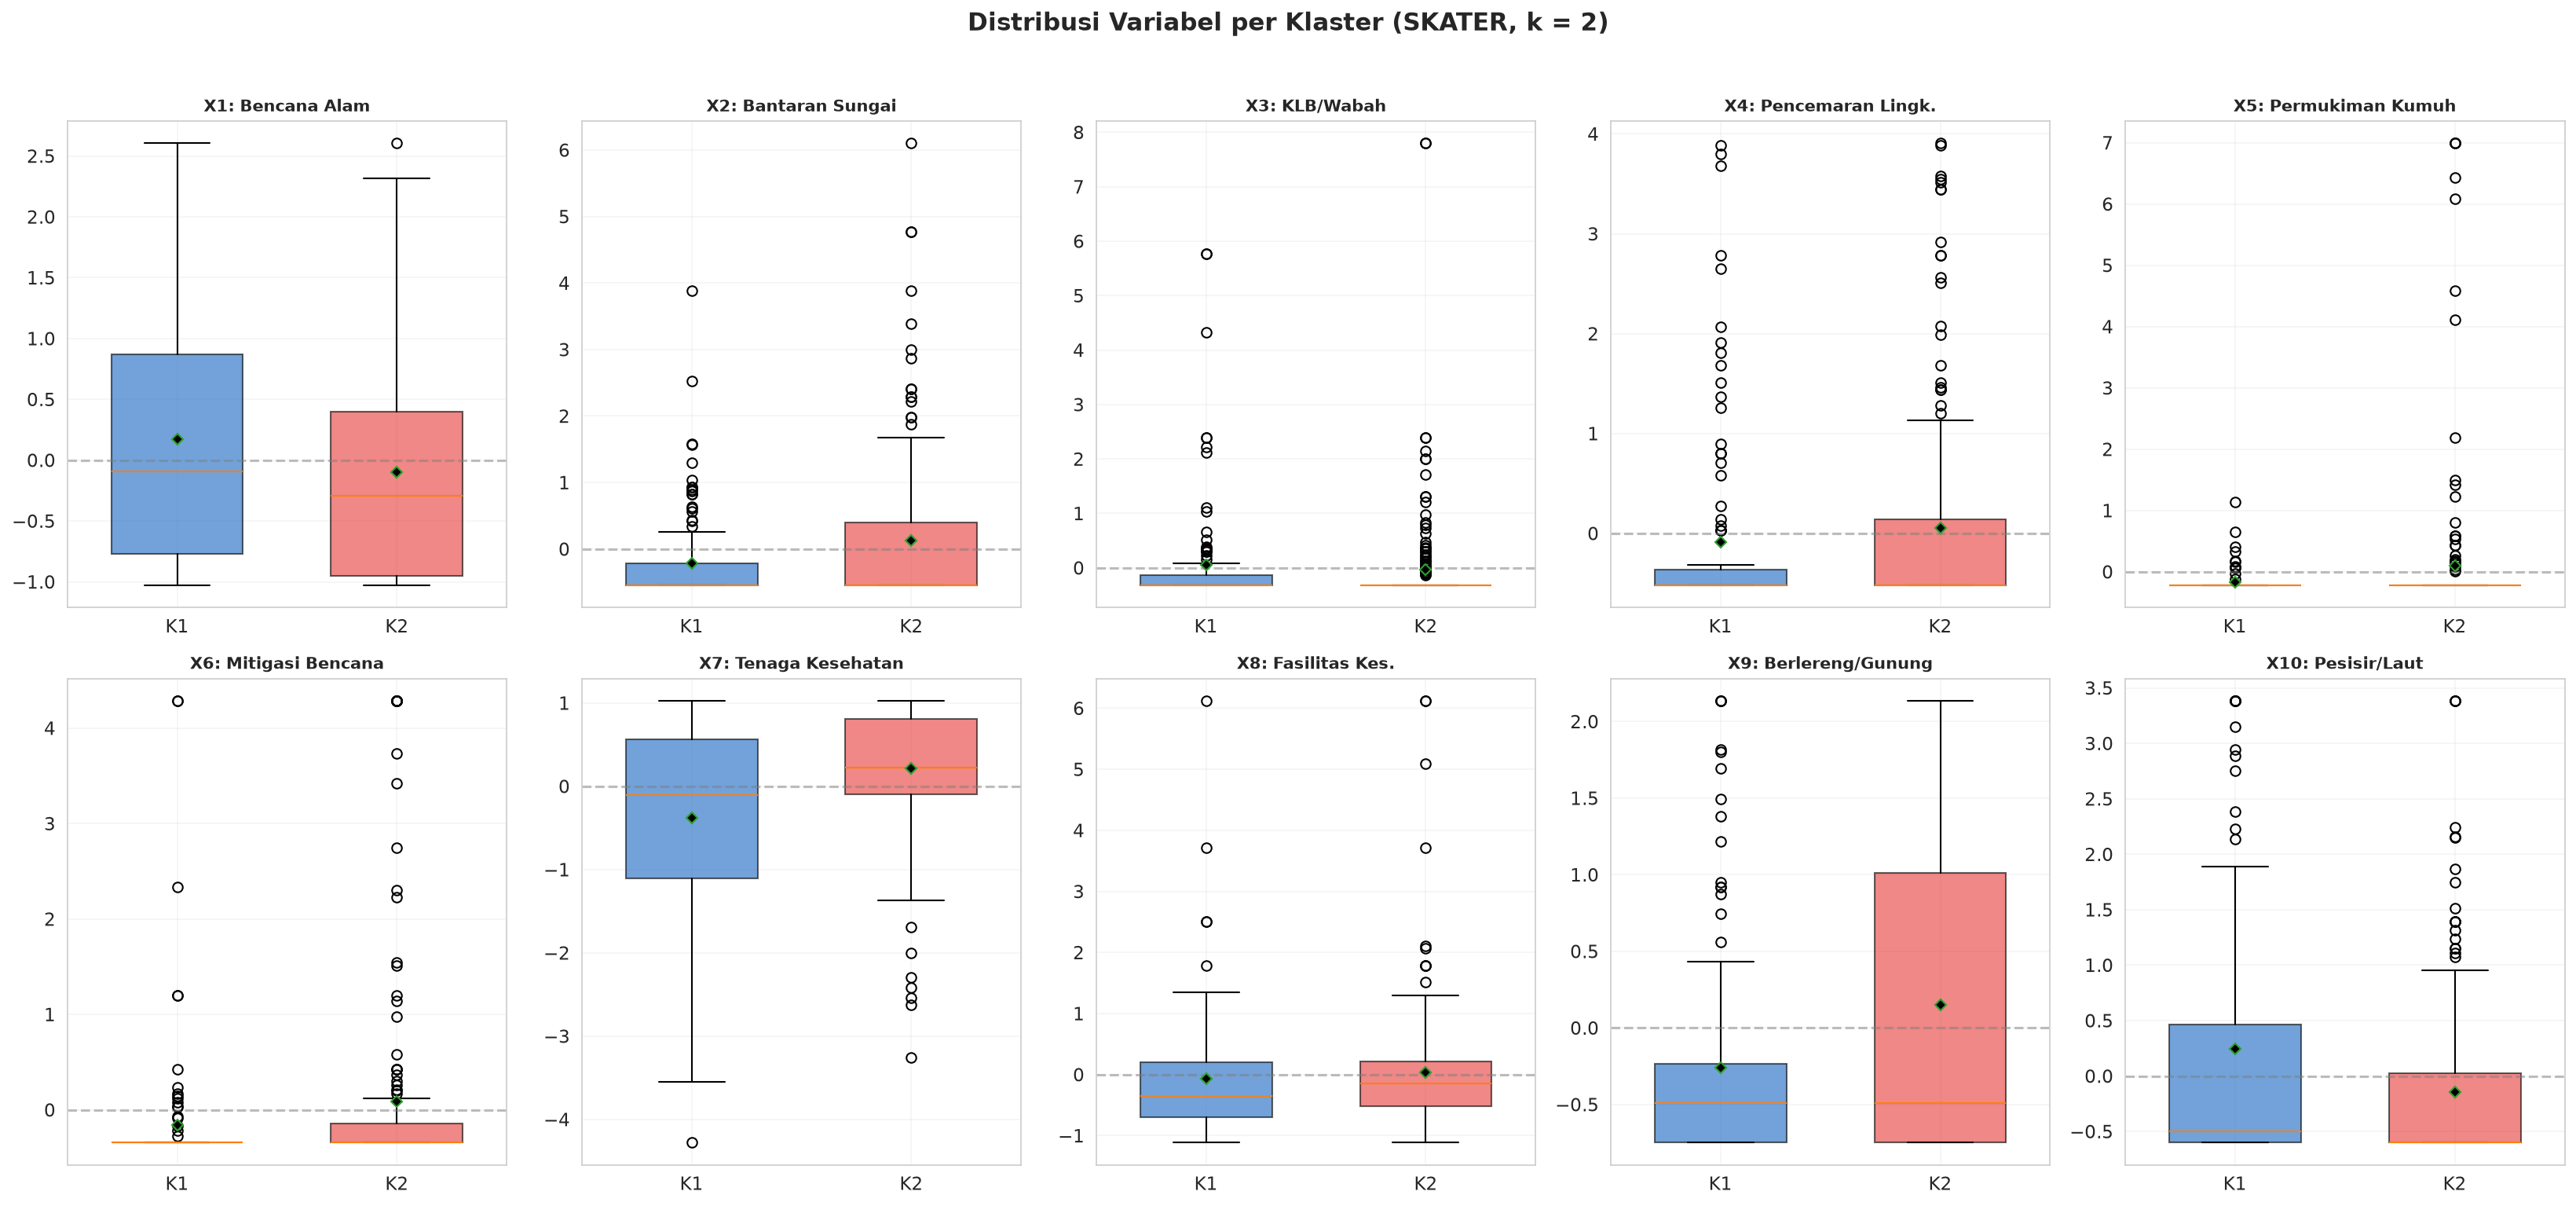

Gambar disimpan: 09_boxplot_distribusi_variabel.png


In [26]:
# ============================================================
# VISUALISASI: Boxplot Distribusi Variabel per Klaster
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(22, 10))

short_labels = {
    'X1': 'Bencana Alam', 'X2': 'Bantaran Sungai', 'X3': 'KLB/Wabah',
    'X4': 'Pencemaran Lingk.', 'X5': 'Permukiman Kumuh',
    'X6': 'Mitigasi Bencana', 'X7': 'Tenaga Kesehatan',
    'X8': 'Fasilitas Kes.', 'X9': 'Berlereng/Gunung', 'X10': 'Pesisir/Laut'
}

for idx, var in enumerate(ATTRS):
    row, col = divmod(idx, 5)
    ax = axes[row, col]
    
    data_plot = []
    tick_labels_list = []
    for c in sorted(gdf['Cluster'].unique()):
        data_plot.append(gdf[gdf['Cluster'] == c][var].values)
        tick_labels_list.append(f'K{c+1}')
    
    bp = ax.boxplot(data_plot, tick_labels=tick_labels_list, patch_artist=True,
                    widths=0.6, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 5})
    
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(PREMIUM_COLORS[i])
        patch.set_alpha(0.6)
    
    ax.set_title(f'{var}: {short_labels[var]}', fontsize=10, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)

fig.suptitle(f'Distribusi Variabel per Klaster (SKATER, k = {BEST_K})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_boxplot_distribusi_variabel.png')
plt.show()
print("Gambar disimpan: 09_boxplot_distribusi_variabel.png")

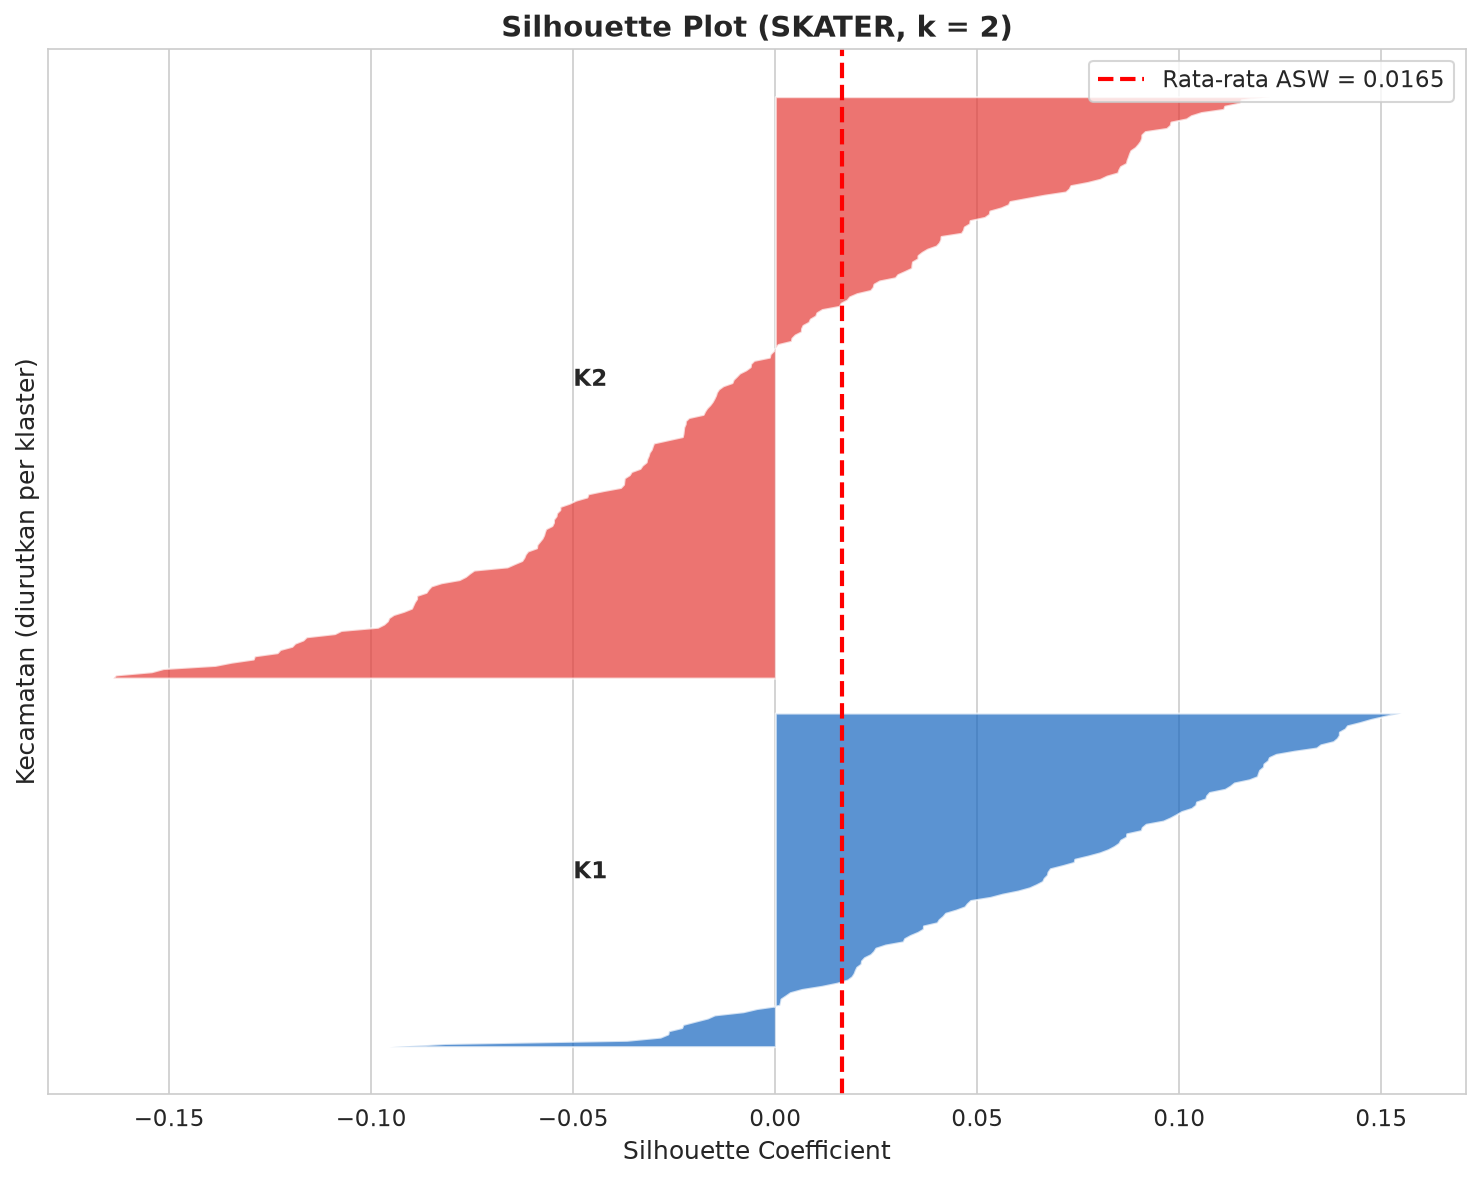

Gambar disimpan: 10_silhouette_plot.png


In [27]:
# ============================================================
# VISUALISASI: Silhouette Plot per Klaster
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

silhouette_vals = silhouette_samples(X_data, best_labels)
avg_silhouette = silhouette_score(X_data, best_labels)

y_lower = 10
for c in sorted(np.unique(best_labels)):
    cluster_sil = silhouette_vals[best_labels == c]
    cluster_sil.sort()
    size_cluster = len(cluster_sil)
    y_upper = y_lower + size_cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=PREMIUM_COLORS[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'K{c+1}',
            fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_silhouette, color='red', linestyle='--', linewidth=2,
           label=f'Rata-rata ASW = {avg_silhouette:.4f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Kecamatan (diurutkan per klaster)', fontsize=12)
ax.set_title(f'Silhouette Plot (SKATER, k = {BEST_K})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_yticks([])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_silhouette_plot.png')
plt.show()
print("Gambar disimpan: 10_silhouette_plot.png")

## Tahap 8b: Validasi Statistik Pasca-Klasterisasi

### Uji Kruskal-Wallis & Post-Hoc Dunn

Untuk membuktikan bahwa klaster yang dihasilkan SKATER memiliki **perbedaan karakteristik kerentanan yang signifikan**, dilakukan:

1. **Uji Kruskal-Wallis** — uji non-parametrik untuk menguji apakah terdapat perbedaan distribusi yang signifikan pada tiap variabel (X1–X10) antarklaster (Sherwani et al., 2021)
   - H₀: Distribusi variabel identik di seluruh klaster
   - H₁: Minimal satu pasangan klaster berbeda secara signifikan
   - Tolak H₀ jika *p-value* < 0,05

2. **Post-Hoc Dunn Test** — jika Kruskal-Wallis signifikan, dilanjutkan dengan Dunn Test (koreksi Bonferroni) untuk mengidentifikasi pasangan klaster mana yang berbeda (Dinno, 2015)

### Referensi
- Sherwani, R. A. K., et al. (2021). Analysis of COVID-19 data using neutrosophic Kruskal Wallis H test. *BMC Medical Research Methodology*, 21, 215.
- Dinno, A. (2015). Nonparametric pairwise multiple comparisons in independent groups using Dunn's test. *The Stata Journal*, 15(1), 292–300.

In [28]:
# ============================================================
# VALIDASI STATISTIK: UJI KRUSKAL-WALLIS
# ============================================================

print("=" * 70)
print("UJI KRUSKAL-WALLIS: Perbedaan Distribusi Antarklaster")
print("=" * 70)
print(f"Jumlah klaster: {BEST_K}")
print(f"Taraf signifikansi: α = 0,05\n")

var_labels = {
    'X1': 'Bencana Alam', 'X2': 'Bantaran Sungai', 'X3': 'KLB/Wabah',
    'X4': 'Pencemaran Lingk.', 'X5': 'Permukiman Kumuh',
    'X6': 'Mitigasi Bencana', 'X7': 'Tenaga Kesehatan',
    'X8': 'Fasilitas Kes.', 'X9': 'Berlereng/Gunung', 'X10': 'Pesisir/Laut'
}

kw_results = []
for var in ATTRS:
    groups = [gdf[gdf['Cluster'] == c][var].values for c in sorted(gdf['Cluster'].unique())]
    stat, pval = kruskal(*groups)
    sig = 'Signifikan' if pval < 0.05 else 'Tidak Signifikan'
    kw_results.append({
        'Variabel': var,
        'Deskripsi': var_labels[var],
        'H-statistic': round(stat, 4),
        'p-value': round(pval, 4),
        'Keputusan': sig
    })

kw_df = pd.DataFrame(kw_results)

print("HASIL UJI KRUSKAL-WALLIS PER VARIABEL")
print("-" * 70)
display(kw_df)

n_sig = sum(1 for r in kw_results if r['Keputusan'] == 'Signifikan')
print(f"\nRINGKASAN:")
print(f"  - Variabel dengan perbedaan signifikan antarklaster: {n_sig}/{len(ATTRS)}")
print(f"  - Variabel tanpa perbedaan signifikan              : {len(ATTRS) - n_sig}/{len(ATTRS)}")

# Simpan tabel
kw_df.to_excel(f'{OUTPUT_DIR}/uji_kruskal_wallis.xlsx', index=False)
print(f"\nTabel disimpan: uji_kruskal_wallis.xlsx")

UJI KRUSKAL-WALLIS: Perbedaan Distribusi Antarklaster
Jumlah klaster: 2
Taraf signifikansi: α = 0,05

HASIL UJI KRUSKAL-WALLIS PER VARIABEL
----------------------------------------------------------------------


,Variabel,Deskripsi,H-statistic,p-value,Keputusan
0,X1,Bencana Alam,4.6363,0.0313,Signifikan
1,X2,Bantaran Sungai,8.1903,0.0042,Signifikan
2,X3,KLB/Wabah,0.2841,0.5940,Tidak Signifikan
3,X4,Pencemaran Lingk.,6.9102,0.0086,Signifikan
4,X5,Permukiman Kumuh,0.9852,0.3209,Tidak Signifikan
5,X6,Mitigasi Bencana,6.4656,0.0110,Signifikan
6,X7,Tenaga Kesehatan,17.7828,0.0000,Signifikan
7,X8,Fasilitas Kes.,4.6432,0.0312,Signifikan
8,X9,Berlereng/Gunung,3.7242,0.0536,Tidak Signifikan
9,X10,Pesisir/Laut,7.0636,0.0079,Signifikan



RINGKASAN:
  - Variabel dengan perbedaan signifikan antarklaster: 7/10
  - Variabel tanpa perbedaan signifikan              : 3/10

Tabel disimpan: uji_kruskal_wallis.xlsx


In [29]:
# ============================================================
# POST-HOC DUNN TEST (untuk variabel signifikan)
# ============================================================

print("=" * 70)
print("POST-HOC DUNN TEST (Koreksi Bonferroni)")
print("Untuk variabel dengan Kruskal-Wallis signifikan")
print("=" * 70)

sig_vars = [r['Variabel'] for r in kw_results if r['Keputusan'] == 'Signifikan']

if len(sig_vars) == 0:
    print("\nTidak ada variabel dengan Kruskal-Wallis signifikan.")
else:
    # Siapkan data untuk Dunn test
    gdf_dunn = gdf[sig_vars + ['Cluster']].copy()
    gdf_dunn['Klaster'] = gdf_dunn['Cluster'].apply(lambda x: f'Klaster {x+1}')

    for var in sig_vars:
        print(f"\n{'─' * 50}")
        print(f"Variabel: {var} ({var_labels[var]})")
        print(f"{'─' * 50}")
        
        # Dunn test dengan koreksi Bonferroni
        dunn_result = sp.posthoc_dunn(
            gdf_dunn, val_col=var, group_col='Klaster', p_adjust='bonferroni'
        )
        
        print("Matriks p-value (Bonferroni adjusted):")
        display(dunn_result.round(4))
        
        # Identifikasi pasangan signifikan
        for i in range(len(dunn_result)):
            for j in range(i+1, len(dunn_result)):
                p = dunn_result.iloc[i, j]
                pair = f"{dunn_result.index[i]} vs {dunn_result.columns[j]}"
                if p < 0.05:
                    print(f"  → {pair}: p = {p:.4f} (SIGNIFIKAN)")
                else:
                    print(f"  → {pair}: p = {p:.4f} (tidak signifikan)")

print(f"\n{'=' * 70}")
print("Post-Hoc Dunn Test selesai.")

POST-HOC DUNN TEST (Koreksi Bonferroni)
Untuk variabel dengan Kruskal-Wallis signifikan

──────────────────────────────────────────────────
Variabel: X1 (Bencana Alam)
──────────────────────────────────────────────────
Matriks p-value (Bonferroni adjusted):


,Klaster 1,Klaster 2
Klaster 1,1.0000,0.0313
Klaster 2,0.0313,1.0000


  → Klaster 1 vs Klaster 2: p = 0.0313 (SIGNIFIKAN)

──────────────────────────────────────────────────
Variabel: X2 (Bantaran Sungai)
──────────────────────────────────────────────────
Matriks p-value (Bonferroni adjusted):


,Klaster 1,Klaster 2
Klaster 1,1.0000,0.0042
Klaster 2,0.0042,1.0000


  → Klaster 1 vs Klaster 2: p = 0.0042 (SIGNIFIKAN)

──────────────────────────────────────────────────
Variabel: X4 (Pencemaran Lingk.)
──────────────────────────────────────────────────
Matriks p-value (Bonferroni adjusted):


...

  → Klaster 1 vs Klaster 2: p = 0.0000 (SIGNIFIKAN)

──────────────────────────────────────────────────
Variabel: X8 (Fasilitas Kes.)
──────────────────────────────────────────────────
Matriks p-value (Bonferroni adjusted):


,Klaster 1,Klaster 2
Klaster 1,1.0000,0.0312
Klaster 2,0.0312,1.0000


  → Klaster 1 vs Klaster 2: p = 0.0312 (SIGNIFIKAN)

──────────────────────────────────────────────────
Variabel: X10 (Pesisir/Laut)
──────────────────────────────────────────────────
Matriks p-value (Bonferroni adjusted):


,Klaster 1,Klaster 2
Klaster 1,1.0000,0.0079
Klaster 2,0.0079,1.0000


  → Klaster 1 vs Klaster 2: p = 0.0079 (SIGNIFIKAN)

Post-Hoc Dunn Test selesai.


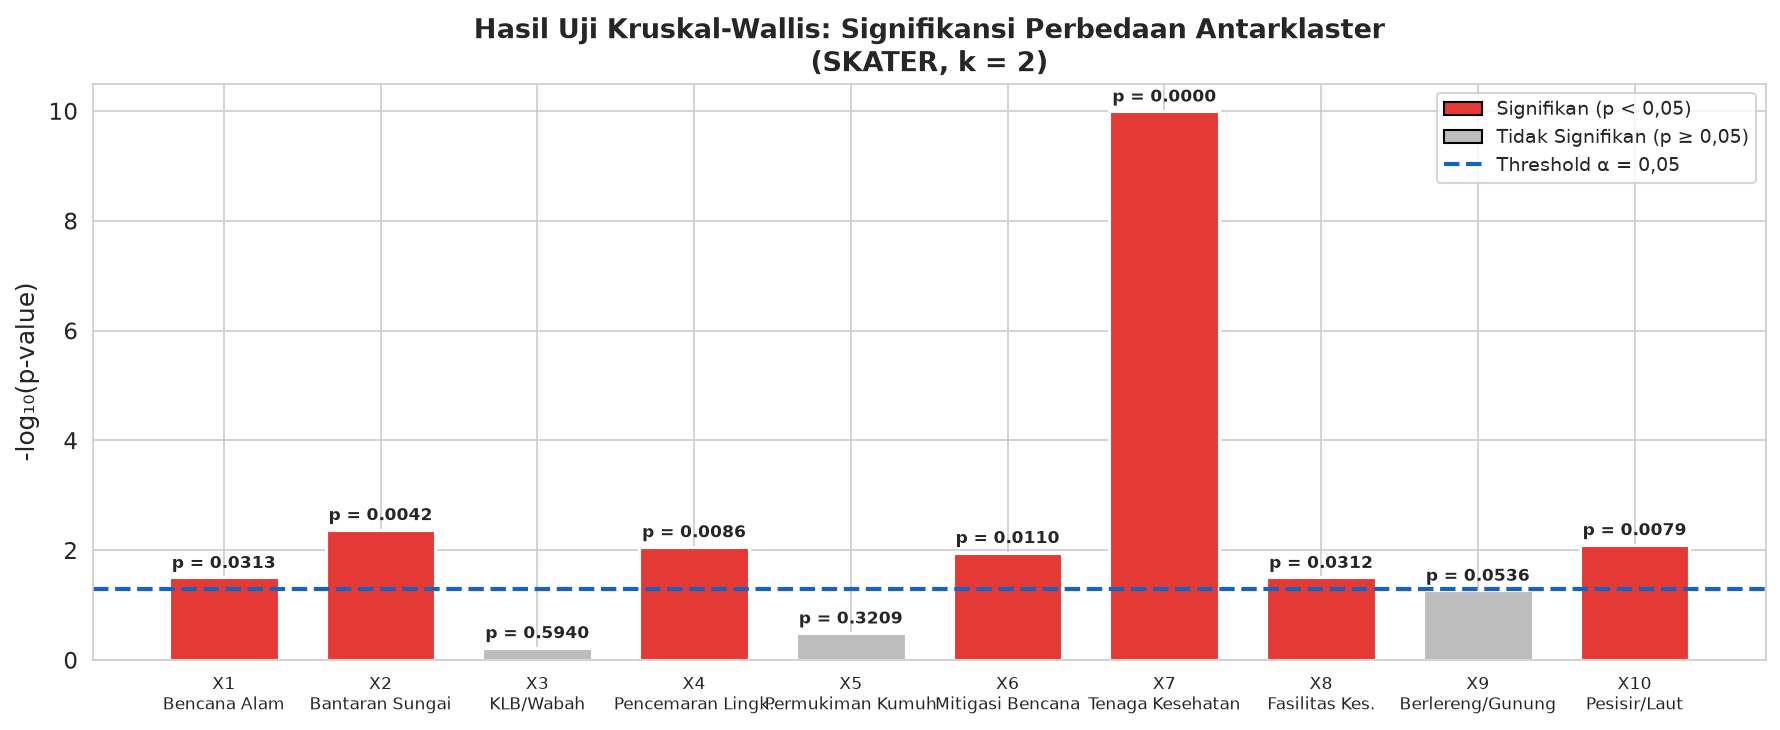

Gambar disimpan: uji_kruskal_wallis_barplot.png


In [30]:
# ============================================================
# VISUALISASI: Hasil Uji Kruskal-Wallis (Heatmap p-value)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

colors_kw = ['#E53935' if r['p-value'] < 0.05 else '#BDBDBD' for r in kw_results]
neg_log_p = [-np.log10(max(r['p-value'], 1e-10)) for r in kw_results]
var_names = [f"{r['Variabel']}\n{r['Deskripsi']}" for r in kw_results]

bars = ax.bar(range(len(ATTRS)), neg_log_p, color=colors_kw,
              edgecolor='white', linewidth=1.5, width=0.7)

# Garis threshold α = 0.05
ax.axhline(y=-np.log10(0.05), color='#1565C0', linewidth=2,
           linestyle='--', label='α = 0,05')

# Tambahkan p-value di atas bar
for i, (bar, res) in enumerate(zip(bars, kw_results)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"p = {res['p-value']:.4f}",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(ATTRS)))
ax.set_xticklabels(var_names, fontsize=8, ha='center')
ax.set_ylabel('-log₁₀(p-value)', fontsize=12)
ax.set_title('Hasil Uji Kruskal-Wallis: Signifikansi Perbedaan Antarklaster\n'
             f'(SKATER, k = {BEST_K})',
             fontsize=13, fontweight='bold')

legend_elements = [
    Patch(facecolor='#E53935', edgecolor='black', label='Signifikan (p < 0,05)'),
    Patch(facecolor='#BDBDBD', edgecolor='black', label='Tidak Signifikan (p ≥ 0,05)'),
    Line2D([0], [0], color='#1565C0', linewidth=2, linestyle='--', label='Threshold α = 0,05')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/uji_kruskal_wallis_barplot.png')
plt.show()
print("Gambar disimpan: uji_kruskal_wallis_barplot.png")

## Tahap 9: Interpretasi Klaster dan Pembahasan

Berikut dilakukan interpretasi karakteristik setiap klaster berdasarkan profil rata-rata variabel kerentanan bencana.

In [31]:
# ============================================================
# INTERPRETASI OTOMATIS BERDASARKAN PROFIL KLASTER
# ============================================================

komponen = {
    'Keterpaparan Bencana': ['X1', 'X2'],
    'Kerentanan Lingkungan & Sosial': ['X3', 'X4', 'X5'],
    'Kapasitas Mitigasi & Respons': ['X6', 'X7', 'X8'],
    'Faktor Geografis Inheren': ['X9', 'X10']
}

means_data = gdf.groupby('Cluster')[ATTRS].mean()

print("=" * 80)
print(f"INTERPRETASI KLASTER KERENTANAN BENCANA (k = {BEST_K})")
print("=" * 80)

for cluster_id in sorted(means_data.index):
    n_kec = np.sum(best_labels == cluster_id)
    kabs = sorted(gdf[gdf['Cluster'] == cluster_id]['Kabupaten'].unique())
    
    print(f"\n{'─' * 70}")
    print(f"KLASTER {cluster_id + 1} ({n_kec} kecamatan)")
    print(f"{'─' * 70}")
    print(f"Kabupaten/Kota yang tercakup: {', '.join(kabs)}")
    
    for komp_name, vars_list in komponen.items():
        komp_mean = means_data.loc[cluster_id, vars_list].mean()
        if komp_mean > 0.5:
            level = "TINGGI"
        elif komp_mean > 0:
            level = "SEDANG-TINGGI"
        elif komp_mean > -0.5:
            level = "SEDANG-RENDAH"
        else:
            level = "RENDAH"
        
        var_details = ', '.join([f'{v}={means_data.loc[cluster_id, v]:.3f}' for v in vars_list])
        print(f"  {komp_name}: {level} ({var_details})")

INTERPRETASI KLASTER KERENTANAN BENCANA (k = 2)

──────────────────────────────────────────────────────────────────────
KLASTER 1 (106 kecamatan)
──────────────────────────────────────────────────────────────────────
Kabupaten/Kota yang tercakup: Aceh Barat, Aceh Barat Daya, Aceh Besar, Aceh Jaya, Aceh Selatan, Aceh Singkil, Aceh Tenggara, Aceh Utara, Bener Meriah, Bireuen, Kota Subulussalam, Nagan Raya, Pidie, Simeulue
  Keterpaparan Bencana: SEDANG-RENDAH (X1=0.174, X2=-0.212)
  Kerentanan Lingkungan & Sosial: SEDANG-RENDAH (X3=0.051, X4=-0.086, X5=-0.170)
  Kapasitas Mitigasi & Respons: SEDANG-RENDAH (X6=-0.156, X7=-0.375, X8=-0.066)
  Faktor Geografis Inheren: SEDANG-RENDAH (X9=-0.259, X10=0.248)

──────────────────────────────────────────────────────────────────────
KLASTER 2 (184 kecamatan)
──────────────────────────────────────────────────────────────────────
Kabupaten/Kota yang tercakup: Aceh Barat, Aceh Barat Daya, Aceh Besar, Aceh Jaya, Aceh Selatan, Aceh Tamiang, Aceh Tengah

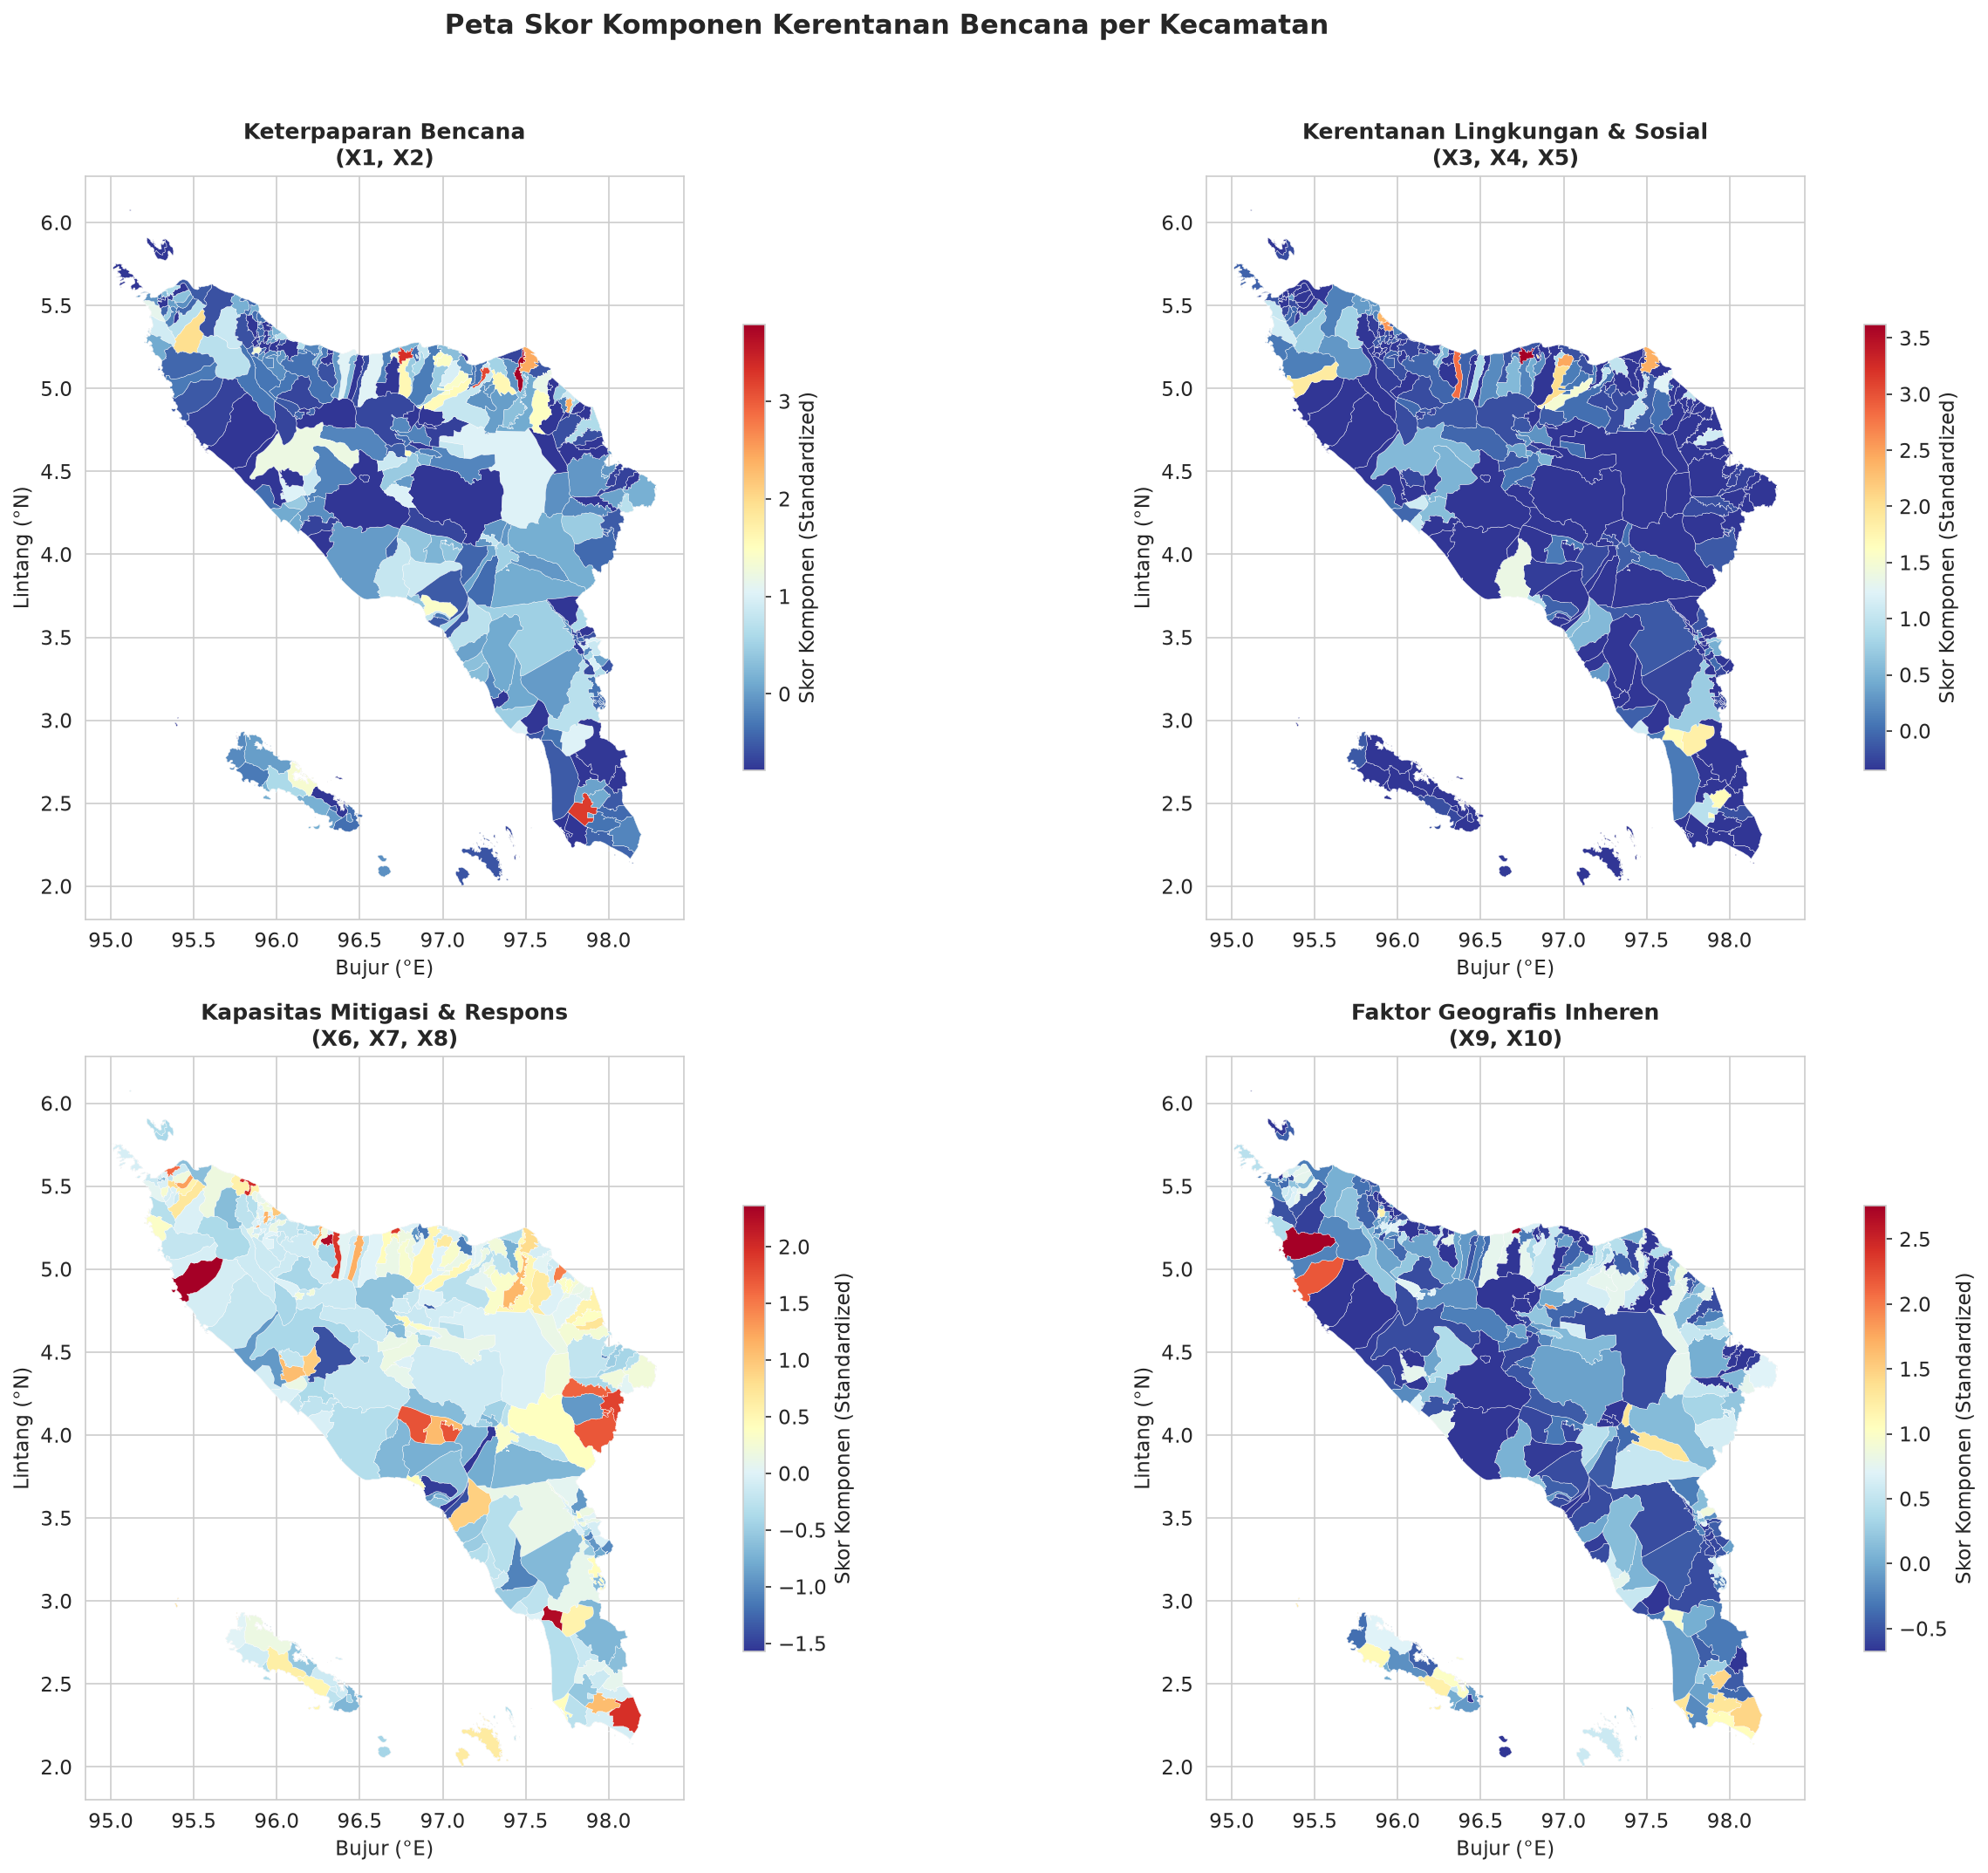

Gambar disimpan: 11_peta_komponen_kerentanan.png


In [32]:
# ============================================================
# VISUALISASI: Peta Klaster per Komponen
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

komponen_vars = {
    'Keterpaparan Bencana\n(X1, X2)': ['X1', 'X2'],
    'Kerentanan Lingkungan & Sosial\n(X3, X4, X5)': ['X3', 'X4', 'X5'],
    'Kapasitas Mitigasi & Respons\n(X6, X7, X8)': ['X6', 'X7', 'X8'],
    'Faktor Geografis Inheren\n(X9, X10)': ['X9', 'X10']
}

for idx, (title, vars_list) in enumerate(komponen_vars.items()):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    gdf[f'komp_{idx}'] = gdf[vars_list].mean(axis=1)
    gdf_raw.plot(ax=ax, color='#F5F5F5', edgecolor='#E0E0E0', linewidth=0.2)  # Background: semua 358 geometri
    gdf.plot(column=f'komp_{idx}', ax=ax, cmap='RdYlBu_r',
             edgecolor='white', linewidth=0.2, legend=True,
             legend_kwds={'label': 'Skor Komponen (Standardized)', 'shrink': 0.6})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Bujur (°E)')
    ax.set_ylabel('Lintang (°N)')
    ax.set_aspect('equal')

fig.suptitle('Peta Skor Komponen Kerentanan Bencana per Kecamatan',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_peta_komponen_kerentanan.png')
plt.show()
print("Gambar disimpan: 11_peta_komponen_kerentanan.png")

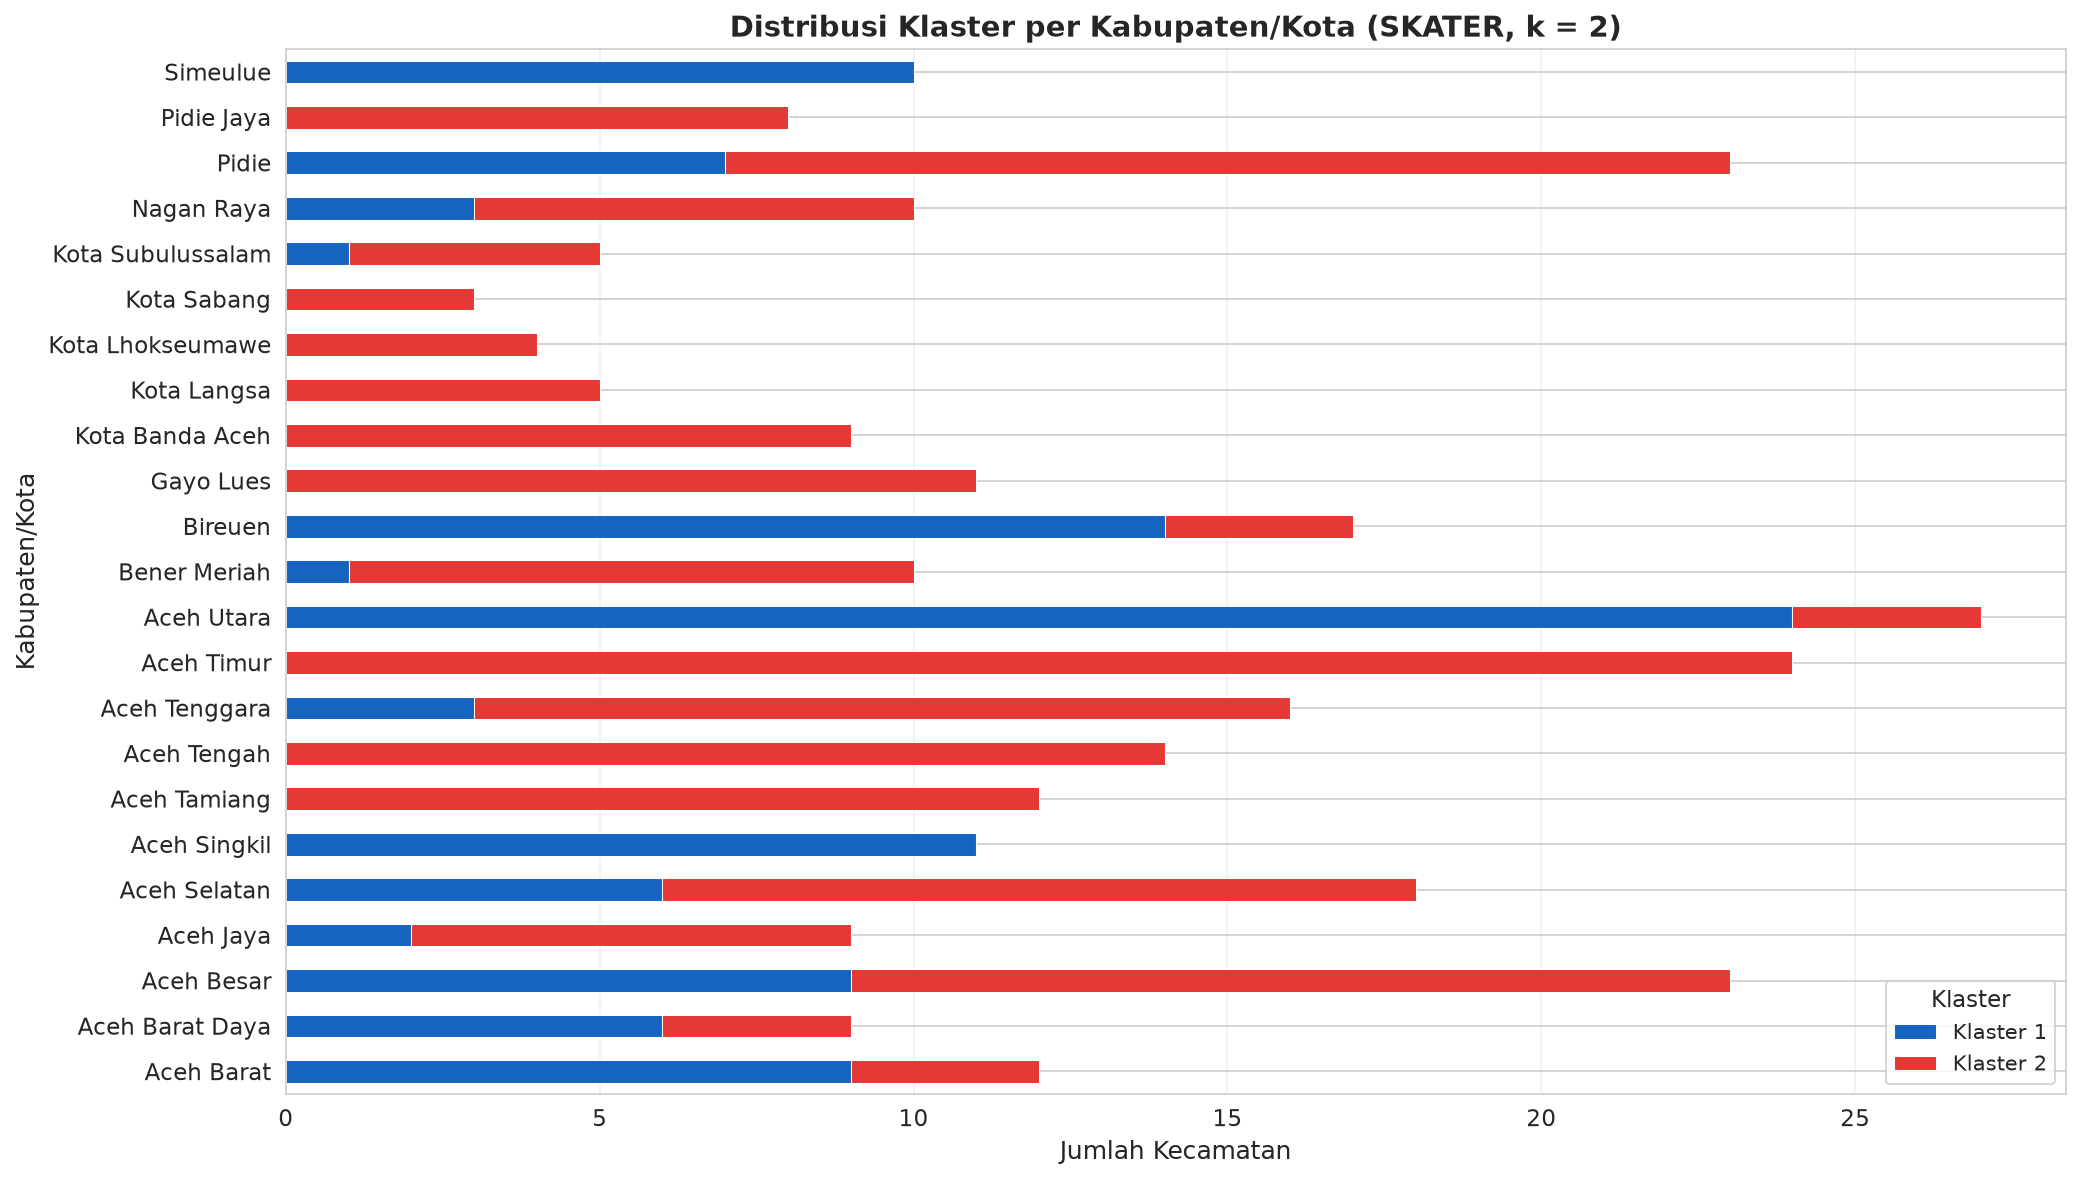

Gambar disimpan: 12_distribusi_klaster_per_kabupaten.png


In [33]:
# ============================================================
# VISUALISASI: Bar Chart Distribusi Klaster per Kabupaten
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

unique_clusters = sorted(np.unique(best_labels))
n_clusters = len(unique_clusters)

cross_tab = pd.crosstab(gdf['Kabupaten'], gdf['Cluster'])
cross_tab.columns = [f'Klaster {c+1}' for c in cross_tab.columns]
cross_tab = cross_tab.sort_index()

cross_tab.plot(
    kind='barh', stacked=True, ax=ax,
    color=PREMIUM_COLORS[:n_clusters],
    edgecolor='white', linewidth=0.5
)

ax.set_title(f'Distribusi Klaster per Kabupaten/Kota (SKATER, k = {BEST_K})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Kecamatan', fontsize=12)
ax.set_ylabel('Kabupaten/Kota', fontsize=12)
ax.legend(fontsize=10, title='Klaster', title_fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_distribusi_klaster_per_kabupaten.png')
plt.show()
print("Gambar disimpan: 12_distribusi_klaster_per_kabupaten.png")

## Tahap 10: Ringkasan Hasil dan Ekspor Data

Tahap akhir meliputi ekspor data hasil klasterisasi dan ringkasan temuan utama.

In [34]:
# ============================================================
# EKSPOR DATA HASIL KLASTERISASI
# ============================================================

result_df = gdf[['Kabupaten', 'Kecamatan', 'Jumlah Desa'] + ATTRS + ['Cluster']].copy()
result_df['Klaster'] = result_df['Cluster'] + 1
result_df = result_df.drop(columns=['Cluster'])

result_df.to_excel(f'{OUTPUT_DIR}/hasil_klasterisasi_SKATER.xlsx', index=False)

print("Data hasil klasterisasi disimpan ke: hasil_klasterisasi_SKATER.xlsx")
print(f"\nTotal kecamatan: {len(result_df)}")
print(f"Jumlah klaster: {result_df['Klaster'].nunique()}")
print(f"\nDistribusi klaster:")
for k in sorted(result_df['Klaster'].unique()):
    print(f"  Klaster {k}: {(result_df['Klaster'] == k).sum()} kecamatan")

Data hasil klasterisasi disimpan ke: hasil_klasterisasi_SKATER.xlsx

Total kecamatan: 290
Jumlah klaster: 2

Distribusi klaster:
  Klaster 1: 106 kecamatan
  Klaster 2: 184 kecamatan


In [35]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================

print("\n" + "=" * 80)
print("RINGKASAN HASIL ANALISIS")
print("Analisis Klasterisasi Kerentanan Bencana Kecamatan di Provinsi Aceh")
print("Berdasarkan Data Potensi Desa 2024 Menggunakan Metode SKATER")
print("=" * 80)

print(f"\n1. Metode           : SKATER (Spatial 'K'luster Analysis by Tree Edge Removal)")
print(f"2. Unit Analisis    : 290 Kecamatan di Provinsi Aceh")
print(f"3. Variabel         : 10 variabel (X1-X10)")
print(f"4. Pembobotan Spasial: Queen Contiguity + Koreksi Konektivitas")
print(f"5. Jumlah Klaster Optimal: k = {BEST_K}")

print(f"\n6. Metrik Evaluasi (k = {BEST_K}):")
print(f"   - Silhouette Score (ASW)       : {results[BEST_K]['ASW']:.4f}")
print(f"   - Davies-Bouldin Index (DBI)   : {results[BEST_K]['DBI']:.4f}")
print(f"   - Calinski-Harabasz Index (CHI) : {results[BEST_K]['CHI']:.4f}")
print(f"   - TSS / Total                  : {results[BEST_K]['TSS_ratio']:.4f}")
print(f"   - Dunn Index                   : {results[BEST_K]['Dunn']:.4f}")

print(f"\n7. Distribusi Klaster:")
for c in sorted(np.unique(best_labels)):
    n_kec = np.sum(best_labels == c)
    pct = n_kec / len(best_labels) * 100
    print(f"   - Klaster {c+1}: {n_kec} kecamatan ({pct:.1f}%)")

print(f"\n8. File Output:")
import glob
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*')):
    print(f"   - {os.path.basename(f)}")

print("\n" + "=" * 80)
print("ANALISIS SELESAI")
print("=" * 80)


RINGKASAN HASIL ANALISIS
Analisis Klasterisasi Kerentanan Bencana Kecamatan di Provinsi Aceh
Berdasarkan Data Potensi Desa 2024 Menggunakan Metode SKATER

1. Metode           : SKATER (Spatial 'K'luster Analysis by Tree Edge Removal)
2. Unit Analisis    : 290 Kecamatan di Provinsi Aceh
3. Variabel         : 10 variabel (X1-X10)
4. Pembobotan Spasial: Queen Contiguity + Koreksi Konektivitas
5. Jumlah Klaster Optimal: k = 2

6. Metrik Evaluasi (k = 2):
   - Silhouette Score (ASW)       : 0.0165
   - Davies-Bouldin Index (DBI)   : 5.3953
   - Calinski-Harabasz Index (CHI) : 7.0048
   - TSS / Total                  : 0.9763
   - Dunn Index                   : 0.0000

7. Distribusi Klaster:
   - Klaster 1: 106 kecamatan (36.6%)
   - Klaster 2: 184 kecamatan (63.4%)

8. File Output:
   - 01_peta_dasar_kecamatan_aceh.png
   - 02_jaringan_ketetanggaan_spasial.png
   - 03_graf_dan_MST.png
   - 04_scree_plot_evaluasi_klaster.png
   - 05_peta_klasterisasi_perbandingan.png
   - 06_peta_klasterisa